# **Obiettivo del Progetto**

Costruire un **modello predittivo di machine learning** per classificare la **potabilità dell’acqua** in base a misurazioni chimiche e fisiche, con un focus su accuratezza, interpretabilità e bilanciamento delle classi.


## **Workflow del Progetto**

### 1. **Preparazione del Dataset**
- Suddivisione iniziale in **training set** e **test set** (quest’ultimo usato **solo nella fase finale**).
- Tutte le analisi, trasformazioni e validazioni sono eseguite **esclusivamente sul training set**, per evitare data leakage.


### 2. **Data Exploration & Cleaning**
- **Analisi Esplorativa dei Dati (EDA)**:
  - Identificazione e visualizzazione di **outlier** per ogni feature rispetto alla variabile target (`Potability`).
  - Calcolo della **percentuale di outlier** su ogni feature.
- **Standardizzazione delle feature**:
  - Applicazione di `StandardScaler()` per migliorare la performance dei modelli sensibili alla scala dei dati (es. KNN).
  - La variabile target viene **esclusa** dalla trasformazione.


### 3. **Analisi del Dataset**

#### Bilanciamento delle Classi
- Analisi della distribuzione della variabile target:
  - La classe 0 (acqua **non potabile**) è leggermente più rappresentata della classe 1 (acqua **potabile**).
- Si è **valutato l’uso dello stratified sampling**, ma si è scelto di mantenere un **campionamento casuale semplice**, poiché i risultati erano migliori e più stabili.

#### Correlazioni tra le Feature
- Calcolo della **matrice di correlazione** tra tutte le feature numeriche.
- Le correlazioni risultano generalmente **basse** (valori prossimi allo 0), senza casi di **multicollinearità** rilevante.
- **Interpretazione**:
  - La bassa correlazione lineare tra le feature suggerisce che **modelli lineari** (come la regressione logistica) **potrebbero non essere i più efficaci**.
  - Sono preferibili **modelli non lineari o ensemble** (es. Random Forest), in grado di catturare pattern più complessi e interazioni tra variabili.

#### Selezione delle Feature
- Applicazione del **Chi-square test** (su variabili discretizzate in 13 bin) per valutare l’associazione tra le feature e la variabile target.
- Sono risultate **statisticamente significative** (p-value < 0.05):
  - `Hardness`
  - `Chloramines`
  - `Sulfate`
- Le altre feature hanno mostrato p-value alti, **indicando scarsa relazione con la target**.
- Queste 3 variabili sono state scelte per la **modellazione con feature selezionate**.


### 4. **Definizione del Task**
- Si tratta di un problema di **classificazione binaria**.
- La metrica principale adottata è l’**accuracy**, ma sono state considerate anche:
  - **Precision**, **Recall**, **F1-score**, **macro avg**, **weighted avg**, ecc.
- Particolare attenzione è stata data alla **classe minoritaria**, valutando anche il **recall della Classe 1** come indicatore chiave.


### 5. **Scelta dei Modelli**
- Sono stati selezionati e confrontati i seguenti modelli:
  - **Logistic Regression** (modello lineare di riferimento)
  - **Random Forest Classifier**
  - **K-Nearest Neighbors**


### 6. **Due Strategie di Modellazione**
- **Strada 1**: addestramento dei modelli su **tutte le feature**.
- **Strada 2**: addestramento dei modelli **solo sulle 3 feature più informative** (`Hardness`, `Chloramines`, `Sulfate`).


### 7. **Valutazione Iniziale dei Modelli**
- Utilizzo della **Stratified K-Fold Cross Validation** per eseguire uno **spot check** iniziale.
- L’obiettivo era individuare i **2 modelli migliori** per ciascuna strada (1 e 2), basandosi sulle metriche aggregate.
- I migliori modelli emersi sono stati:
  - **Random Forest**
  - **K-Nearest Neighbors**


### 8. **Tuning degli Iperparametri**
- Ottimizzazione tramite **GridSearchCV** con cross-validation interna.
- Per ogni modello è stata costruita una **griglia personalizzata** di iperparametri, basata sui risultati preliminari della **RandomizedSearchCV**.
- La griglia è stata costruita in modo intelligente con un sistema di **espansione controllata** dei valori, evitando configurazioni non valide (es. `min_samples_leaf` < 2).


### 9. **Valutazione Finale sul Test Set**
- I modelli finali (uno per ciascuna strategia) sono stati testati sul **test set mai visto prima**.
- I risultati principali sono stati:
  - **Random Forest (tutte le feature)**: Accuracy ~ 0.692
  - **KNN (tutte le feature)**: Accuracy ~ 0.672
  - **Random Forest (feature selezionate)**: Accuracy ~ 0.637
  - **KNN (feature selezionate)**: Accuracy ~ 0.637

- Riflettendo su questi numeri:
  - I modelli con tutte le feature **generalizzano leggermente meglio**.
  - La **classe minoritaria** è in ogni caso difficile da classificare (recall Classe 1 sempre sotto 0.40), confermando l’impatto del class imbalance.


### 10. **Confronto tra le Due Strategie**
- La strategia **con tutte le feature** ha fornito migliori risultati globali, ma quella con feature selezionate è risultata **molto più veloce** da addestrare.
- **Random Forest** è il modello con le performance più alte, ma **KNN** ha tempi di addestramento **molto più rapidi**, risultando **più competitivo in contesti real-time o a basse risorse**.
- Siamo quindi di fronte a una **scelta di compromesso**:
  - Preferiamo **migliore accuratezza** (Random Forest)?
  - Oppure **rapidità e semplicità di implementazione** (KNN)?


## **Discussione Finale**

- Il progetto ha affrontato un problema ambientale importante, con approccio rigoroso, trasparente e ben documentato.
- I risultati ottenuti sono **coerenti con la natura del dataset**, che presenta **debole segnale predittivo**, **assenza di relazioni lineari forti** e un **leggero squilibrio di classe**.
- Il miglioramento ottenuto con la **selezione delle feature** è stato utile sia in termini di efficienza computazionale, sia per migliorare **l’interpretabilità** del modello.
- La **classe minoritaria** continua a rappresentare una sfida; future estensioni del lavoro potrebbero includere:
  - Tecniche di **bilanciamento** (SMOTE, class weights, under/over-sampling)
  - Modellazione basata su **cost-sensitive learning** personalizzato
  - Esplorazione di algoritmi più sofisticati (es. XGBoost, LightGBM)

# **Analisi Esplorativa Iniziale**

Per iniziare con il dataset, ho eseguito alcune operazioni preliminari fondamentali per esplorarlo e prepararlo all'analisi. Ho cominciato caricando le librerie ed il dataset dal file CSV 'water_potability.csv' e visualizzando le prime righe per avere un'idea delle informazioni contenute. Successivamente, ho standardizzato i nomi delle colonne, convertendoli tutti in minuscolo, per evitare eventuali problemi con riferimenti incoerenti.

Ho proceduto con un controllo dei duplicati, assicurandomi che non fossero presenti righe ripetute nel dataset. Qualora ne fossero stati rilevati, avrei rimosso i duplicati per preservare l'integrità dei dati.

Per ottenere una panoramica più dettagliata dei dati, ho utilizzato il metodo `info()` che mi ha fornito informazioni sui tipi di variabili e sulla presenza di valori nulli. Ho anche effettuato un riepilogo statistico delle colonne numeriche tramite il metodo `describe()`, per comprendere la distribuzione e le caratteristiche principali dei dati, come media, deviazione standard, percentili e valori estremi.

Un aspetto cruciale che ho affrontato è stato il trattamento dei valori mancanti. Ho identificato le colonne con valori NaN e, anziché eliminarli, ho preferito sostituirli con la mediana delle rispettive colonne, per mantenere la distribuzione dei dati senza introdurre distorsioni.

Infine, ho verificato nuovamente la presenza di valori NaN nel dataset, assicurandomi che tutte le operazioni di pulizia e imputazione fossero state eseguite correttamente.

Questa fase è stata fondamentale per rendere il dataset pronto per l'analisi successiva, riducendo il rischio di errori legati a dati incoerenti o incompleti.

--- 


In [ ]:
import os
import math
import json
import base64
import joblib
import inspect
import tempfile
import numpy as np
import pandas as pd
from time import time
import seaborn as sns
from tabulate import tabulate
from sklearn.base import clone
import matplotlib.pyplot as plt
from itertools import zip_longest
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_score

In [2]:
# Carichiamo il dataset dal file CSV 'water_potability.csv' in un DataFrame
df = pd.read_csv('water_potability.csv')

# Visualizziamo le prime righe del DataFrame per controllare i dati
df.head()  # Mostra le prime 5 righe del dataset

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Convertiamo tutti i nomi delle colonne in minuscolo
df.columns = df.columns.str.lower()

# Visualizziamo i nomi delle colonne dopo la conversione
df.columns  # Restituisce i nomi delle colonne in minuscolo

Index(['ph', 'hardness', 'solids', 'chloramines', 'sulfate', 'conductivity',
       'organic_carbon', 'trihalomethanes', 'turbidity', 'potability'],
      dtype='object')

In [ ]:
# Analizzo le varie informazioni del df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   hardness         3276 non-null   float64
 2   solids           3276 non-null   float64
 3   chloramines      3276 non-null   float64
 4   sulfate          2495 non-null   float64
 5   conductivity     3276 non-null   float64
 6   organic_carbon   3276 non-null   float64
 7   trihalomethanes  3114 non-null   float64
 8   turbidity        3276 non-null   float64
 9   potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
# Controllo che non ci siano casi duplicati ritornando il numero totale di righe duplicate
df.duplicated().sum()

# Se ci fossero stai dei duplicati sarebbero stati tolti con
#df = df.drop_duplicates(ignore_index=True)

0

In [ ]:
# Controllo ogni colonna se ci sono e la quantità di valori nan
df.isnull().sum()

ph                 491
hardness             0
solids               0
chloramines          0
sulfate            781
conductivity         0
organic_carbon       0
trihalomethanes    162
turbidity            0
potability           0
dtype: int64

## 1. **Preparazione del Dataset**

In questa fase, ho suddiviso il dataset in due set distinti: **training set** (80%) e **test set** (20%). La divisione è stata effettuata sia con il metodo standard di **train-test split** senza stratificazione, sia utilizzando l'opzione **stratify**, che cerca di mantenere la stessa proporzione di classi presenti nell'intero dataset.  
In generale, lo **stratified sampling** è preferito nei problemi di classificazione, poiché assicura che entrambe le classi siano rappresentate in modo proporzionato sia nel training set che nel test set. Questo è particolarmente utile quando si lavora con **classi sbilanciate**, per evitare che il modello apprenda in modo distorto o sottovaluti una delle classi.

Ecco i risultati ottenuti dalle due modalità:

- **Senza Stratify**: La distribuzione delle classi nel training set era composta dal **60.53%** di campioni della classe 0 e dal **39.47%** di campioni della classe 1. Lo sbilanciamento risultante tra le due classi è stato pari al **21.06%**.  
- **Con Stratify**: Utilizzando lo stratified sampling, la distribuzione è risultata molto simile, con il **60.99%** di campioni della classe 0 e il **39.01%** di campioni della classe 1. In questo caso, lo sbilanciamento è stato leggermente maggiore, pari al **21.98%**.

Dopo aver confrontato i due approcci, ho deciso di adottare la divisione **senza stratify**, in quanto lo sbilanciamento riscontrato è leggermente inferiore (**21.06%** contro **21.98%**). In questo specifico caso, il livello di sbilanciamento non è così marcato da giustificare l’utilizzo forzato dello stratified sampling, e una suddivisione casuale potrebbe riflettere in modo più naturale la distribuzione reale dei dati.


## **Gestione dei Valori Mancanti (Imputazione)**

Successivamente, ho applicato una procedura di **imputazione** per gestire la presenza di valori mancanti all’interno del dataset. L’imputazione è una tecnica che permette di sostituire i **valori nulli o NaN** con valori plausibili, così da rendere i dati compatibili con i modelli di machine learning (che non supportano valori mancanti).

### Strategia adottata

Ho utilizzato una funzione personalizzata chiamata `impute_and_save_or_load`, che consente:

- di gestire **separatamente** colonne numeriche e categoriche;
- di applicare strategie differenti a seconda della tipologia di dato;
- di **salvare** o **caricare** automaticamente gli imputers (strumenti che memorizzano le regole di imputazione);
- di garantire **reproducibilità** attraverso un seme casuale (`random_seed`);
- di riutilizzare lo stesso imputatore su nuovi dataset di test futuri.

### Dettagli tecnici

- **Per le colonne numeriche** è stata scelta la strategia `'median'`, che sostituisce i valori mancanti con la mediana della distribuzione della colonna nel training set. La mediana è una scelta robusta, soprattutto in presenza di **outlier**.
  
- **Per le colonne categoriche** è stata adottata la strategia `'proportional'`, che sostituisce i valori mancanti campionando casualmente tra le modalità esistenti in base alla loro **distribuzione empirica** (frequenze relative). Questo approccio mantiene la **distribuzione statistica originale** della variabile, evitando distorsioni.

In questo modo, è stato possibile non solo **imputare** correttamente i dati di training e test, ma anche **salvare** le informazioni usate per l'imputazione (nel file `imputers.pkl`), così da poterle riapplicare in modo coerente su qualsiasi nuovo set di dati, evitando "data leakage".

In [ ]:
# Impostiamo il seed del generatore di numeri casuali di NumPy a 0
# Questo garantisce che i numeri casuali generati siano gli stessi ad ogni esecuzione
np.random.seed(0)

# Carica i dati e le etichette
# La variabile `feature` contiene tutte le colonne delle caratteristiche (variabili indipendenti) del dataset,
# tranne l'ultima colonna che rappresenta il target (etichetta). Queste caratteristiche sono quelle che il modello userà per fare le previsioni.
feature = df.drop(columns=['potability'])  # Le caratteristiche di ciascun vino (tutte le colonne tranne l'ultima)

# La variabile `target` contiene la colonna dell'etichetta, che rappresenta le classi a cui appartengono i campioni di vino.
# Questo target sarà ciò che il modello dovrà predire in base alle caratteristiche fornite.
target = df['potability']  # Il target (classi del vino, ultima colonna)

# # Assegno i dati alle variabili `X` e `y`
X = feature  # `X` contiene le caratteristiche che il modello userà per fare le previsioni
y = target   # `y` contiene il target, che sono le etichette (classi) che il modello deve prevedere

# Funzione per calcolare e stampare la distribuzione delle classi e lo sbilanciamento
def calcola_distribuzione_e_sbilanciamento(y_list):
    """
    Calcola e stampa la distribuzione delle classi, lo sbilanciamento in percentuale, la somma dei conteggi
    e la somma delle percentuali per ciascun set, iterando su tutte le colonne (serie) nella lista di input.
    
    :param y_list: Lista di Serie o DataFrame da cui calcolare la distribuzione delle classi e lo sbilanciamento.
    """
    for i, y in enumerate(y_list):
        print(f"Elaborazione della variabile {i + 1}: {y.name if hasattr(y, 'name') else f'Serie {i + 1}'}")
        
        # Calcola la distribuzione delle classi
        distribuzione = y.value_counts()
        distribuzione_percentuale = (distribuzione / len(y) * 100).round(2)
        
        # Calcolo dello sbilanciamento come differenza tra la percentuale della classe più grande e quella più piccola
        sbilanciamento = distribuzione_percentuale.max() - distribuzione_percentuale.min()

        # Calcola la somma dei conteggi e delle percentuali
        somma_conteggi = distribuzione.sum()
        somma_percentuali = distribuzione_percentuale.sum()

        # Stampa la distribuzione e lo sbilanciamento per ciascuna serie
        print("Distribuzione delle classi (classe X: conteggio | percentuale):")
        for classe, conteggio in distribuzione.items():
            print(f"Classe {classe}: {conteggio} | {distribuzione_percentuale[classe]:.2f}%")
        
        print(f"Somma dei conteggi: {somma_conteggi}")
        print(f"Somma delle percentuali: {somma_percentuali:.2f}%")
        print(f"Sbilanciamento: {sbilanciamento:.2f}%\n")


def trova_miglior_split(X, y, test_size=0.2):
    """
    Esegue uno split con e senza stratify e seleziona il migliore in base allo sbilanciamento, stampando le info in stile richiesto.
    
    :param X: Il set di dati con le caratteristiche.
    :param y: Le etichette di classe.
    :param test_size: La percentuale di dati da usare per il set di test (default 0.2 per 20%).
    :return: I set X_train, X_test, y_train, y_test con lo split migliore.
    """
    frame = inspect.currentframe().f_back
    locals_ = frame.f_locals

    # Estraggo i nomi tramite inspect per X e y
    nome_X = next((k for k, v in locals_.items() if id(v) == id(X)), "X")
    nome_y = next((k for k, v in locals_.items() if id(v) == id(y)), "y")

    risultati = []

    for stratify, descr in [(False, "senza stratify"), (True, "con stratify")]:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42,
            stratify=(y if stratify else None)
        )

        # Output in formato richiesto
        dist = y_train.value_counts()
        dist_pct = (dist / len(y_train) * 100).round(2)
        sbilanciamento = (dist_pct.max() - dist_pct.min()).round(2)

        # Usa nome dinamico per il set X_train e y_train
        print(f"Distribuzione delle classi per {nome_X} - {nome_y} ({descr}):")
        for cls, cnt in dist.items():
            print(f"  Classe {cls}: {cnt} | {dist_pct[cls]:.2f}%")
        print(f"  Somma conteggi: {dist.sum()}")
        print(f"  Somma percentuali: {dist_pct.sum():.2f}%")
        print(f"  Sbilanciamento: {sbilanciamento:.2f}%")
        print(f"  Percentuale split: {100 * (1 - test_size):.2f}% per train, {100 * test_size:.2f}% per test\n")

        risultati.append({
            'descrizione': descr,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'sbilanciamento': sbilanciamento
        })

    print(f"Confronto sbilanciamento per {nome_X} - {nome_y}:")
    for r in risultati:
        print(f"  Sbilanciamento {r['descrizione'].upper()}: {r['sbilanciamento']:.2f}%")

    migliore = min(risultati, key=lambda r: r['sbilanciamento'])
    print(f"\nScelto split {migliore['descrizione'].upper()} per {nome_X} - {nome_y}.")

    return (
        migliore['X_train'],
        migliore['X_test'],
        migliore['y_train'],
        migliore['y_test'],
    )

# === APPLICAZIONE ===

# In questo esempio, la percentuale di test è 20% (0.2), ma puoi modificarlo
X_train, X_test, y_train, y_test = trova_miglior_split(X, y, test_size=0.2)

# Imposta il nome della colonna target (assicurati che y_train e y_test abbiano lo stesso nome)
y_train.name = y.name
y_test.name = y.name

# Mostra la distribuzione finale scelta
#calcola_distribuzione_e_sbilanciamento([y_train])

# Applica SMOTE sul training set per bilanciare le classi
# smote = SMOTE(random_state=42)
# X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

Distribuzione delle classi per feature - target (senza stratify):
  Classe 0: 1586 | 60.53%
  Classe 1: 1034 | 39.47%
  Somma conteggi: 2620
  Somma percentuali: 100.00%
  Sbilanciamento: 21.06%
  Percentuale split: 80.00% per train, 20.00% per test

Distribuzione delle classi per feature - target (con stratify):
  Classe 0: 1598 | 60.99%
  Classe 1: 1022 | 39.01%
  Somma conteggi: 2620
  Somma percentuali: 100.00%
  Sbilanciamento: 21.98%
  Percentuale split: 80.00% per train, 20.00% per test

Confronto sbilanciamento per feature - target:
  Sbilanciamento SENZA STRATIFY: 21.06%
  Sbilanciamento CON STRATIFY: 21.98%

Scelto split SENZA STRATIFY per feature - target.


In [8]:
# Controllo che non ci siano casi duplicati ritornando il numero totale di righe duplicate
X_train.duplicated().sum()

# Se ci fossero stai dei duplicati sarebbero stati tolti con
#df = df.drop_duplicates(ignore_index=True)

0

In [9]:
# Analizzo le varie informazioni del df
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2620 entries, 233 to 3174
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2225 non-null   float64
 1   hardness         2620 non-null   float64
 2   solids           2620 non-null   float64
 3   chloramines      2620 non-null   float64
 4   sulfate          1989 non-null   float64
 5   conductivity     2620 non-null   float64
 6   organic_carbon   2620 non-null   float64
 7   trihalomethanes  2493 non-null   float64
 8   turbidity        2620 non-null   float64
dtypes: float64(9)
memory usage: 204.7 KB


In [10]:
# Controllo ogni colonna se ci sono e la quantità di valori nan
X_train.isnull().sum()

ph                 395
hardness             0
solids               0
chloramines          0
sulfate            631
conductivity         0
organic_carbon       0
trihalomethanes    127
turbidity            0
dtype: int64

In [11]:
# Utilizziamo il metodo describe() per ottenere un riepilogo statistico delle colonne numeriche
X_train.describe()

# Il metodo describe() restituisce le seguenti statistiche:
# - count: il numero di valori non nulli per ciascuna colonna
# - mean: la media dei valori numerici
# - std: la deviazione standard dei valori numerici
# - min: il valore minimo per ciascuna colonna
# - 25%: il 25° percentile (primo quartile)
# - 50%: il 50° percentile (mediana o secondo quartile)
# - 75%: il 75° percentile (terzo quartile)
# - max: il valore massimo per ciascuna colonna

,ph,hardness,solids,chloramines,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
count,2225.000000,2620.000000,2620.000000,2620.000000,1989.000000,2620.000000,2620.000000,2493.000000,2620.000000
mean,7.088976,196.448911,22066.597807,7.107867,333.653302,426.420949,14.251860,66.355132,3.959903
std,1.587250,32.579075,8835.078941,1.588035,41.550603,81.189543,3.285042,16.245992,0.779162
min,0.000000,73.492234,728.750830,0.352000,129.000000,181.483754,4.371899,8.175876,1.492207
25%,6.106760,176.832962,15736.815715,6.108402,307.987458,365.712099,12.054236,55.697400,3.429438
50%,7.021617,196.901673,20921.203012,7.107117,332.759029,422.033283,14.155598,66.621027,3.940678
75%,8.058136,216.690772,27203.707180,8.097686,360.086901,481.179357,16.519916,77.373813,4.497655
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000


In [12]:
# Controllo ogni colonna se ci sono e la quantità di valori nan
X_train.isnull().sum()

ph                 395
hardness             0
solids               0
chloramines          0
sulfate            631
conductivity         0
organic_carbon       0
trihalomethanes    127
turbidity            0
dtype: int64

In [ ]:
# === Funzione di imputazione con salvataggio/caricamento ===
def impute_and_save_or_load(X_train: pd.DataFrame, X_test: pd.DataFrame, save_path: str = None, num_strategy: str = 'median', cat_strategy: str = 'proportional', random_seed: int = None, overwrite: bool = False):
    """
    Imputa i valori mancanti nei dataset X_train e X_test. Supporta diverse strategie per
    colonne numeriche e categoriche, e consente il salvataggio/caricamento degli imputers.

    Parametri:
    - X_train: DataFrame di addestramento con possibili valori NaN.
    - X_test: DataFrame di test con possibili valori NaN.
    - save_path: Percorso dove salvare o caricare il file contenente gli imputers.
    - num_strategy: Strategia di imputazione per le colonne numeriche ('mean', 'median', ecc.).
    - cat_strategy: Strategia per le colonne categoriche ('most_frequent' o 'proportional').
    - random_seed: Per la riproducibilità nella scelta casuale ('proportional').
    - overwrite: Se True, forza il ricalcolo e la riscrittura del file imputers.

    Ritorna:
    - X_train_imputed: DataFrame di training con valori imputati.
    - X_test_imputed: DataFrame di test con valori imputati.
    """

    rng = np.random.default_rng(random_seed)  # Inizializza un generatore casuale

    # Sostituisce eventuali stringhe 'nan' con veri np.nan per coerenza
    X_train = X_train.replace('nan', np.nan)
    X_test = X_test.replace('nan', np.nan)

    # Identifica colonne numeriche e categoriche
    num_cols = X_train.select_dtypes(include=['number']).columns
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

    # Copie dei DataFrame per non modificarli in-place
    X_train_imputed = X_train.copy()
    X_test_imputed = X_test.copy()

    imputers = {}

    # === CASO 1: Se esiste il file e overwrite è False, carica gli imputers ===
    if save_path and os.path.exists(save_path) and not overwrite:
        print(f"Caricamento imputers da {save_path}")
        imputers = joblib.load(save_path)

        # Applica imputazione numerica
        if len(num_cols) > 0:
            X_train_imputed[num_cols] = imputers['num_imputer'].transform(X_train[num_cols])
            X_test_imputed[num_cols] = imputers['num_imputer'].transform(X_test[num_cols])

        # Applica imputazione categorica
        if cat_strategy == 'most_frequent':
            X_train_imputed[cat_cols] = imputers['cat_imputer'].transform(X_train[cat_cols])
            X_test_imputed[cat_cols] = imputers['cat_imputer'].transform(X_test[cat_cols])
        elif cat_strategy == 'proportional':
            for col in cat_cols:
                probs = imputers['cat_distribution'].get(col, {})
                mask_train = X_train[col].isna()
                mask_test = X_test[col].isna()
                X_train_imputed.loc[mask_train, col] = rng.choice(
                    list(probs), size=mask_train.sum(), p=list(probs.values()))
                X_test_imputed.loc[mask_test, col] = rng.choice(
                    list(probs), size=mask_test.sum(), p=list(probs.values()))

    # === CASO 2: Sovrascrittura forzata del file imputers ===
    elif save_path and overwrite:
        print(f"Sovrascrittura degli imputers e salvataggio in {save_path}")

        # Imputazione numerica
        if len(num_cols) > 0:
            imputer_num = SimpleImputer(strategy=num_strategy)
            imputer_num.fit(X_train[num_cols])
            X_train_imputed[num_cols] = imputer_num.transform(X_train[num_cols])
            X_test_imputed[num_cols] = imputer_num.transform(X_test[num_cols])
            imputers['num_imputer'] = imputer_num

        # Imputazione categorica
        if len(cat_cols) > 0:
            if cat_strategy == 'most_frequent':
                imputer_cat = SimpleImputer(strategy='most_frequent')
                imputer_cat.fit(X_train[cat_cols])
                X_train_imputed[cat_cols] = imputer_cat.transform(X_train[cat_cols])
                X_test_imputed[cat_cols] = imputer_cat.transform(X_test[cat_cols])
                imputers['cat_imputer'] = imputer_cat
            elif cat_strategy == 'proportional':
                cat_distributions = {}
                for col in cat_cols:
                    value_counts = X_train[col].value_counts(normalize=True, dropna=True)
                    probs = value_counts.to_dict()
                    mask_train = X_train[col].isna()
                    mask_test = X_test[col].isna()
                    X_train_imputed.loc[mask_train, col] = rng.choice(
                        list(probs), size=mask_train.sum(), p=list(probs.values()))
                    X_test_imputed.loc[mask_test, col] = rng.choice(
                        list(probs), size=mask_test.sum(), p=list(probs.values()))
                    cat_distributions[col] = probs
                imputers['cat_distribution'] = cat_distributions

        joblib.dump(imputers, save_path)
        print(f"Nuovi imputers salvati in {save_path}")

    # === CASO 3: File assente, ma save_path specificato: salva nuovo imputatore ===
    elif save_path and not os.path.exists(save_path):
        print(f"Calcolo e salvataggio nuovi imputers in {save_path}")

        if len(num_cols) > 0:
            imputer_num = SimpleImputer(strategy=num_strategy)
            imputer_num.fit(X_train[num_cols])
            X_train_imputed[num_cols] = imputer_num.transform(X_train[num_cols])
            X_test_imputed[num_cols] = imputer_num.transform(X_test[num_cols])
            imputers['num_imputer'] = imputer_num

        if len(cat_cols) > 0:
            if cat_strategy == 'most_frequent':
                imputer_cat = SimpleImputer(strategy='most_frequent')
                imputer_cat.fit(X_train[cat_cols])
                X_train_imputed[cat_cols] = imputer_cat.transform(X_train[cat_cols])
                X_test_imputed[cat_cols] = imputer_cat.transform(X_test[cat_cols])
                imputers['cat_imputer'] = imputer_cat
            elif cat_strategy == 'proportional':
                cat_distributions = {}
                for col in cat_cols:
                    value_counts = X_train[col].value_counts(normalize=True, dropna=True)
                    probs = value_counts.to_dict()
                    mask_train = X_train[col].isna()
                    mask_test = X_test[col].isna()
                    X_train_imputed.loc[mask_train, col] = rng.choice(
                        list(probs), size=mask_train.sum(), p=list(probs.values()))
                    X_test_imputed.loc[mask_test, col] = rng.choice(
                        list(probs), size=mask_test.sum(), p=list(probs.values()))
                    cat_distributions[col] = probs
                imputers['cat_distribution'] = cat_distributions

        joblib.dump(imputers, save_path)
        print(f"Imputers salvati in {save_path}")

    # === CASO 4: Nessun salvataggio o caricamento ===
    else:
        print(f"Imputazione senza salvataggio")

        if len(num_cols) > 0:
            imputer_num = SimpleImputer(strategy=num_strategy)
            X_train_imputed[num_cols] = imputer_num.fit_transform(X_train[num_cols])
            X_test_imputed[num_cols] = imputer_num.transform(X_test[num_cols])

        if len(cat_cols) > 0:
            if cat_strategy == 'most_frequent':
                imputer_cat = SimpleImputer(strategy='most_frequent')
                X_train_imputed[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])
                X_test_imputed[cat_cols] = imputer_cat.transform(X_test[cat_cols])
            elif cat_strategy == 'proportional':
                for col in cat_cols:
                    value_counts = X_train[col].value_counts(normalize=True, dropna=True)
                    probs = value_counts.to_dict()
                    mask_train = X_train[col].isna()
                    mask_test = X_test[col].isna()
                    X_train_imputed.loc[mask_train, col] = rng.choice(
                        list(probs), size=mask_train.sum(), p=list(probs.values()))
                    X_test_imputed.loc[mask_test, col] = rng.choice(
                        list(probs), size=mask_test.sum(), p=list(probs.values()))

    return X_train_imputed, X_test_imputed


#X_train, X_test = impute_and_save_or_load(X_train, X_test)
X_train, X_test = impute_and_save_or_load(X_train, X_test, random_seed=42, save_path="imputers.pkl")#, overwrite=True)# num_strategy="mean"#, cat_strategy="proportional")
X_train.isnull().sum()


Calcolo e salvataggio nuovi imputers in imputers.pkl
Imputers salvati in imputers.pkl


ph                 0
hardness           0
solids             0
chloramines        0
sulfate            0
conductivity       0
organic_carbon     0
trihalomethanes    0
turbidity          0
dtype: int64

In [19]:
# Utilizziamo il metodo describe() per ottenere un riepilogo statistico delle colonne numeriche
X_train.describe()

# Il metodo describe() restituisce le seguenti statistiche:
# - count: il numero di valori non nulli per ciascuna colonna
# - mean: la media dei valori numerici
# - std: la deviazione standard dei valori numerici
# - min: il valore minimo per ciascuna colonna
# - 25%: il 25° percentile (primo quartile)
# - 50%: il 50° percentile (mediana o secondo quartile)
# - 75%: il 75° percentile (terzo quartile)
# - max: il valore massimo per ciascuna colonna

,ph,hardness,solids,chloramines,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
count,2620.000000,2620.000000,2620.000000,2620.000000,2620.000000,2620.000000,2620.000000,2620.000000,2620.000000
mean,7.078820,196.448911,22066.597807,7.107867,333.437925,426.420949,14.251860,66.368021,3.959903
std,1.462864,32.579075,8835.078941,1.588035,36.202788,81.189543,3.285042,15.847302,0.779162
min,0.000000,73.492234,728.750830,0.352000,129.000000,181.483754,4.371899,8.175876,1.492207
25%,6.284835,176.832962,15736.815715,6.108402,317.290224,365.712099,12.054236,56.387748,3.429438
50%,7.021617,196.901673,20921.203012,7.107117,332.759029,422.033283,14.155598,66.621027,3.940678
75%,7.862157,216.690772,27203.707180,8.097686,350.398274,481.179357,16.519916,76.782036,4.497655
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000


# 2. Data Exploration & Cleaning

#### Analisi esplorativa (EDA)

Durante la fase esplorativa è stata condotta un'analisi visiva e quantitativa per individuare la presenza di **outlier** nelle variabili numeriche, in relazione alla variabile target `Potability`.

Per ciascuna feature numerica, sono stati generati **boxplot separati per classe** (`0` = acqua non potabile, `1` = acqua potabile). Questi grafici hanno permesso di evidenziare la distribuzione dei dati e la presenza di valori anomali.

In parallelo, è stata calcolata la **percentuale di outlier** per ciascuna feature e classe, utilizzando il criterio dell’**Intervallo Interquartile (IQR)**. Le percentuali più elevate sono state osservate nelle variabili `sulfate` e `ph`, in particolare nella classe `0`.

**Nessun outlier è stato rimosso in questa fase**, ma i risultati ottenuti sono stati utili per valutare la qualità dei dati e preparare il preprocessing successivo.

#### Visualizzazione

Sono stati creati boxplot per ciascuna feature numerica rispetto al target, al fine di rappresentare graficamente la presenza di outlier e la distribuzione dei valori all’interno delle due classi. Questi grafici hanno aiutato a identificare pattern, simmetrie o asimmetrie tra i gruppi.


#### Standardizzazione delle Variabili

Dopo l’esplorazione iniziale, è stata applicata la **standardizzazione delle variabili numeriche** per uniformare le scale delle feature e rendere i dati adatti all’addestramento dei modelli di machine learning.  
In particolare, è stato utilizzato lo **StandardScaler** di `sklearn`, che trasforma ogni variabile in modo che abbia **media 0** e **deviazione standard 1**. Questo tipo di trasformazione è fondamentale per evitare che variabili con valori numericamente maggiori influenzino in modo sproporzionato il modello.

La standardizzazione è stata effettuata tramite una **funzione personalizzata** che:
- Applica la trasformazione **solo alle colonne numeriche**, mantenendo inalterate quelle categoriche;
- Esegue il **fit dello scaler solo sul training set** (`X_train`) per evitare data leakage;
- Applica lo stesso scaler anche al test set (`X_test`) per garantire coerenza tra i dati;
- Permette di **salvare lo scaler su file**, così da poterlo riutilizzare su dati futuri.

La variabile target (`Potability`) è stata esclusa dallo scaling, come da buona prassi. Grazie a questo approccio, il dataset è stato preparato in modo corretto e coerente per le fasi successive di modellazione.

Percentuali di outlier:


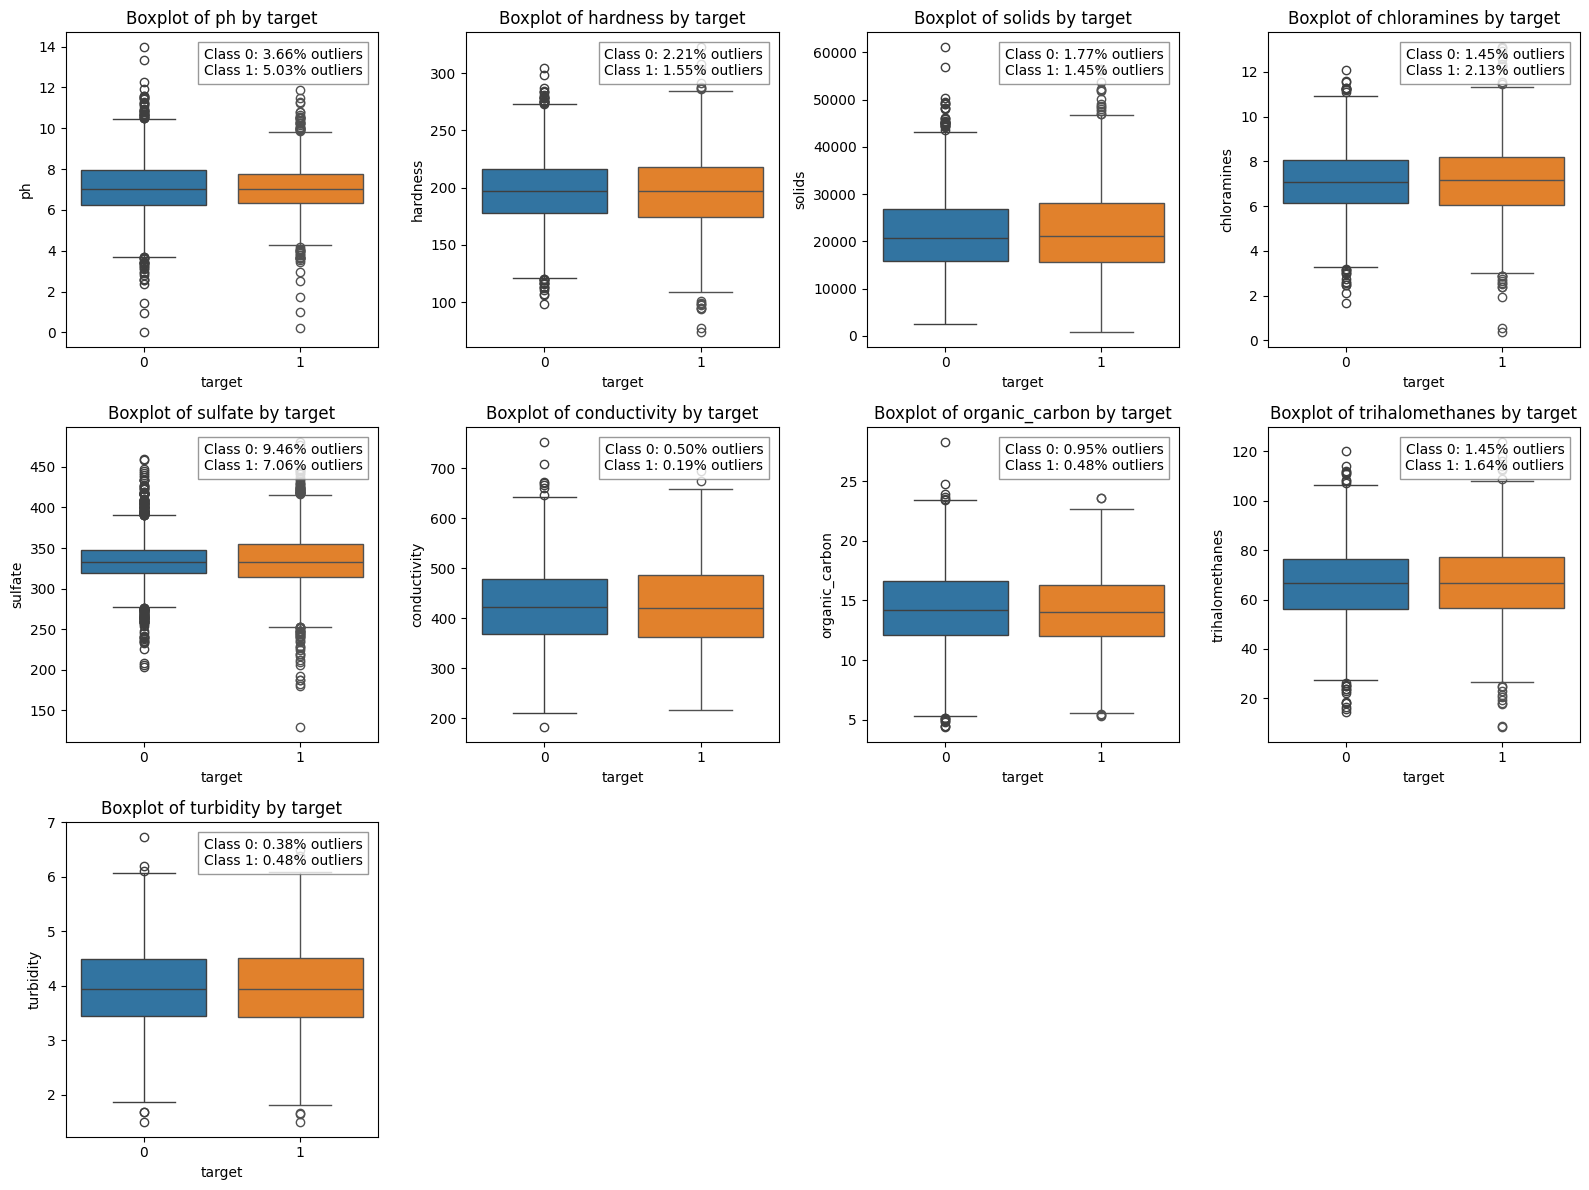

Percentuale di outlier per ciascuna feature e classe:
ph_class_0: 3.66%
ph_class_1: 5.03%
hardness_class_0: 2.21%
hardness_class_1: 1.55%
solids_class_0: 1.77%
solids_class_1: 1.45%
chloramines_class_0: 1.45%
chloramines_class_1: 2.13%
sulfate_class_0: 9.46%
sulfate_class_1: 7.06%
conductivity_class_0: 0.50%
conductivity_class_1: 0.19%
organic_carbon_class_0: 0.95%
organic_carbon_class_1: 0.48%
trihalomethanes_class_0: 1.45%
trihalomethanes_class_1: 1.64%
turbidity_class_0: 0.38%
turbidity_class_1: 0.48%


In [20]:
def detect_outliers_improved(X, y, togli_outlier="no", standardizzare="no", X_test=None):
    """
    Analizza gli outlier nelle feature numeriche rispetto al target e, se richiesto, li rimuove.
    Inoltre, se richiesto, standardizza le feature numeriche.

    Parametri:
    - X: DataFrame contenente le feature di addestramento.
    - y: Serie target (variabile di risposta).
    - togli_outlier: 'si' per rimuovere gli outlier, 'no' per mantenerli. Default 'no'.
    - standardizzare: 'si' per standardizzare le feature, 'no' per non farlo. Default 'no'.
    - X_test: DataFrame delle feature di test (necessario per la standardizzazione).

    Restituisce:
    - Dizionario con percentuali di outlier per ciascuna feature e classe target.
    - DataFrame modificato X e y (se togli_outlier='si').
    """
    # Verifica che i dati di input non siano vuoti
    if X.empty or y.empty:
        raise ValueError("X o y sono vuoti. Assicurati di fornire dati validi.")
    
    # Combina le feature (X) con il target (y) in un unico DataFrame
    df = X.copy()  # Copia il DataFrame di input
    df['target'] = y.values  # Aggiungi il target come colonna nel DataFrame
    
    # Dizionario per memorizzare le percentuali di outlier per ciascuna feature e classe
    outliers = {}
    
    # Seleziona solo le colonne numeriche (escludendo il target)
    num_columns = df.select_dtypes(include=[np.number]).columns.drop('target', errors='ignore')
    n = len(num_columns)  # Numero di feature numeriche

    # Funzione per calcolare e visualizzare i boxplot
    def plot_boxplots():
        # Definisce la griglia di plot per visualizzare i boxplot delle feature
        ncols = min(4, n)  # Imposta al massimo 4 colonne per la griglia
        nrows = (n + ncols - 1) // ncols  # Calcola il numero di righe necessarie
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
        axes = np.array(axes).flatten()  # Converte la griglia in un array per una gestione uniforme

        # Ciclo su ogni colonna numerica (ogni feature)
        for i, column in enumerate(num_columns):
            ax = axes[i]  # Ottieni il subplot per la feature corrente

            # Calcola e visualizza gli outlier per ciascuna classe del target
            for target_value in df['target'].unique():
                df_class = df[df['target'] == target_value]  # Dati della classe corrente

                if len(df_class) == 0:
                    continue  # Se la classe è vuota, salta il ciclo

                # Calcolo dei quartili e dell'Interquartile Range (IQR)
                Q1 = df_class[column].quantile(0.25)
                Q3 = df_class[column].quantile(0.75)
                IQR = Q3 - Q1  # Calcolo dell'Interquartile Range
                lower_bound = Q1 - 1.5 * IQR  # Limite inferiore per gli outlier
                upper_bound = Q3 + 1.5 * IQR  # Limite superiore per gli outlier

                # Identificazione degli outlier
                is_outlier = (df_class[column] < lower_bound) | (df_class[column] > upper_bound)

                # Calcolo della percentuale di outlier per la classe corrente
                outlier_percentage = is_outlier.sum() / len(df_class) * 100

                # Memorizza la percentuale di outlier nel dizionario
                outliers[f"{column}_class_{target_value}"] = outlier_percentage

                # Crea il boxplot per visualizzare gli outlier per la classe
                sns.boxplot(x=df_class['target'], y=df_class[column], ax=axes[i])
                axes[i].set_title(f'Boxplot of {column} by target')

            # Aggiungi una legenda con le percentuali di outlier per ciascuna classe
            info_text = "\n".join(
                [f"Class {val}: {outliers[f'{column}_class_{val}']:.2f}% outliers"
                 for val in sorted(df['target'].unique())
                 if not np.isnan(outliers[f"{column}_class_{val}"])]  # Ignora NaN
            )

            # Se ci sono informazioni da visualizzare, aggiungi il testo sul grafico
            if info_text:  # Solo se ci sono dati validi
                ax.text(0.95, 0.95, info_text,
                       transform=ax.transAxes,
                       ha='right', va='top',
                       bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

        # Rimuove i subplots che non sono stati utilizzati (se ce ne sono)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        # Organizza bene i grafici nel layout
        plt.tight_layout()
        plt.show()

    # Esegui il plot iniziale dei boxplot prima della rimozione degli outlier
    print("Percentuali di outlier:")
    plot_boxplots()
    
    # Stampa le percentuali iniziali di outlier
    print("Percentuale di outlier per ciascuna feature e classe:")
    for feature, percentage in outliers.items():
        print(f"{feature}: {percentage:.2f}%")

    # Rimuove gli outlier se richiesto
    if togli_outlier == "si":
        # Elimina gli outlier nel dataset
        for column in num_columns:
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

        # Rimuove le righe corrispondenti agli outlier anche dal target
        X_cleaned = df.drop(columns='target')
        y_cleaned = df['target']

        # Stampa i risultati finali
        print("\nPercentuale di outlier dopo la rimozione:")
        plot_boxplots()

        print("Percentuale di outlier per ciascuna feature e classe (dopo la rimozione):")
        for feature, percentage in outliers_percentage.items():
            print(f"{feature}: {percentage:.2f}%")

        # **Applica la standardizzazione prima del return se richiesto**
        if standardizzare == "si":
            
            if X_test is None:
                raise ValueError("X_test deve essere fornito per la standardizzazione dei dati di test.")

            scaler = StandardScaler()
            X_cleaned_scaled = pd.DataFrame(scaler.fit_transform(X_cleaned), columns=X_cleaned.columns)
            
            # Standardizza anche X_test con lo stesso scaler
            X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
            print("\nStandardizzazione applicata alle feature numeriche.")
        else:
            X_cleaned_scaled = X_cleaned.copy()  # Se non si standardizza, usa il dataset senza cambiamenti
            X_test_scaled = X_test.copy()

        # Restituisci il dataset pulito e standardizzato (se richiesto)
        return X_cleaned_scaled, X_test_scaled, y_cleaned, outliers  # Restituisce il dataset pulito e i calcoli

    # Se non si rimuovono gli outlier, restituisce solo i calcoli
    return outliers


# Esempio di utilizzo con rimozione degli outlier e standardizzazione:
outliers_percentage = detect_outliers_improved(X_train, y_train)
#X_cleaned_train_scaled, X_cleaned_test_scaled, y_cleaned, outliers_percentage = detect_outliers_improved(X_train, y_train, togli_outlier="si", standardizzare="si", X_test=X_test)

In [ ]:
def scale_numeric_only(X_train: pd.DataFrame, X_test: pd.DataFrame, y_train=None, y_test=None, save_path: str = None, scaler_type: str = "standard", overwrite: bool = False):
    """
    Applica scaling alle sole colonne numeriche con scaler selezionabile.
    Le colonne categoriche restano inalterate. Indici resettati. Scaler salvabile o caricabile da file.

    :param X_train: DataFrame di training
    :param X_test: DataFrame di test
    :param y_train: Serie target di training (opzionale)
    :param y_test: Serie target di test (opzionale)
    :param save_path: Percorso per salvare/caricare scaler (opzionale)
    :param scaler_type: Tipo di scaler: "standard", "minmax", "robust", "maxabs"
    :param overwrite: Se True, forza il rifit dello scaler anche se esiste già
    :return: X_train_scaled_df, X_test_scaled_df, y_train, y_test
    """

    # Dizionario degli scaler disponibili
    scaler_options = {
        "standard": StandardScaler,
        "minmax": MinMaxScaler,
        "robust": RobustScaler,
        "maxabs": MaxAbsScaler
    }

    if scaler_type not in scaler_options:
        raise ValueError(f"Scaler '{scaler_type}' non supportato. Scegli tra: {list(scaler_options.keys())}")

    num_cols = X_train.select_dtypes(include='number').columns
    cat_cols = X_train.select_dtypes(exclude='number').columns

    # Caso 1: Caricamento scaler esistente
    if save_path and os.path.exists(save_path) and not overwrite:
        print(f"Caricamento scaler da {save_path}")
        scaler = joblib.load(save_path)

    # Caso 2: Sovrascrittura e salvataggio nuovo scaler
    elif save_path and overwrite:
        print(f"Fitting nuovo scaler: {scaler_type} e sovrascrizione salvataggio in {save_path}")
        scaler = scaler_options[scaler_type]()
        scaler.fit(X_train[num_cols])
        joblib.dump(scaler, save_path)

    # Caso 3: Primo salvataggio di uno scaler
    elif save_path and not os.path.exists(save_path):
        print(f"Fitting nuovo scaler: {scaler_type} e salvataggio in {save_path}")
        scaler = scaler_options[scaler_type]()
        scaler.fit(X_train[num_cols])
        joblib.dump(scaler, save_path)

    # Caso 4: Nessun file specificato, solo fit
    else:
        print(f"Fitting nuovo scaler senza salvataggio: {scaler_type}")
        scaler = scaler_options[scaler_type]()
        scaler.fit(X_train[num_cols])

    # Applica scaling alle colonne numeriche
    X_train_scaled_np = scaler.transform(X_train[num_cols])
    X_test_scaled_np = scaler.transform(X_test[num_cols])

    # Costruisce nuovi DataFrame scalati
    X_train_scaled_df = pd.DataFrame(X_train_scaled_np, columns=num_cols)
    X_test_scaled_df = pd.DataFrame(X_test_scaled_np, columns=num_cols)

    # Aggiunge eventuali colonne categoriche
    if len(cat_cols) > 0:
        X_train_scaled_df = pd.concat([X_train_scaled_df, X_train[cat_cols].reset_index(drop=True)], axis=1)
        X_test_scaled_df = pd.concat([X_test_scaled_df, X_test[cat_cols].reset_index(drop=True)], axis=1)

    # Reset indici
    X_train_scaled_df = X_train_scaled_df.reset_index(drop=True)
    X_test_scaled_df = X_test_scaled_df.reset_index(drop=True)

    if y_train is not None:
        y_train = pd.Series(y_train).reset_index(drop=True)
    if y_test is not None:
        y_test = pd.Series(y_test).reset_index(drop=True)

    return X_train_scaled_df, X_test_scaled_df, y_train, y_test



X_train_scaled, X_test_scaled, y_train, y_test = scale_numeric_only(X_train, X_test, y_train, y_test, save_path="scaler_standard.pkl")#, overwrite=True)
# # Caso 1: Applica lo scaler senza caricare/salvare nulla (scaler standard di default)
# X_train_scaled, X_test_scaled, y_train, y_test = scale_numeric_only(X_train, X_test)

# # Caso 2: Carica lo scaler esistente (se disponibile), altrimenti lo calcola
# X_train_scaled, X_test_scaled, y_train, y_test = scale_numeric_only(X_train, X_test, save_path="scaler.pkl")

# # Caso 3: Ricalcola lo scaler e sovrascrivi il file
# X_train_scaled, X_test_scaled, y_train, y_test = scale_numeric_only(X_train, X_test, save_path="scaler.pkl", overwrite=True)


Fitting nuovo scaler: standard e salvataggio in scaler_standard.pkl


# 3. Analisi del Dataset

#### Bilanciamento delle Classi

È stato analizzato il bilanciamento della variabile target `Potability`, osservando una **leggera asimmetria** nella distribuzione tra le classi `0` (non potabile) e `1` (potabile).  
Sebbene fosse stata considerata l’ipotesi di adottare uno **stratified sampling** per mantenere costante la distribuzione delle classi tra training e test set, si è deciso di **non applicarlo**, in quanto produceva un **lievissimo peggioramento** nella distribuzione generale. Si è dunque mantenuto un **campionamento casuale semplice**, ritenuto adeguato alla situazione.

**Differenze tra campionamento casuale semplice e stratificato:**

- **Campionamento casuale semplice**: consiste nella selezione casuale degli esempi dal dataset, senza alcuna considerazione per la distribuzione delle classi. Questo tipo di campionamento può risultare problematico se il dataset è sbilanciato, poiché potrebbe portare a una rappresentazione insufficiente della classe meno frequente nel test set, riducendo la capacità predittiva del modello per quella classe.
  
- **Campionamento stratificato**: garantisce che le proporzioni delle classi nel training e nel test set siano simili a quelle presenti nell'intero dataset. Questo approccio è particolarmente utile nei casi di dataset sbilanciati, in quanto preserva la distribuzione delle classi, riducendo il rischio che alcune classi vengano sottorappresentate nel test set e migliorando la generalizzazione del modello.

Nel nostro caso, tuttavia, l'uso dello **stratified sampling** ha portato a un **lievissimo peggioramento** nella distribuzione complessiva delle classi, per cui si è preferito utilizzare il **campionamento casuale semplice**, che ha mostrato risultati sufficientemente buoni.

---

#### Analisi delle Correlazioni

**Quanto sono correlate le variabili? Ci sono delle relazioni lineari?**  
Per rispondere a queste domande, sono state calcolate le **matrici di correlazione** tra tutte le feature numeriche del dataset standardizzato. Questo ha permesso di identificare la forza e il segno delle relazioni lineari tra le variabili indipendenti.

La visualizzazione tramite **heatmap** ha evidenziato:

- Un livello generalmente **basso di correlazione** tra le variabili, con valori prossimi allo zero.
- Nessuna evidente **multicollinearità**, cioè assenza di coppie di variabili fortemente correlate (tutte le correlazioni sono rimaste sotto soglie critiche).
- Alcune **relazioni deboli**, ad esempio tra `solids` e `sulfate`, o tra `ph` e `hardness`, ma senza impatti sostanziali.

**Interpretazione e impatto sui modelli lineari:**  
Il basso livello di correlazione lineare tra le feature suggerisce che **modelli lineari semplici (come la regressione logistica)** potrebbero **non catturare adeguatamente** le dinamiche sottostanti al problema. In altre parole, l’assenza di forti relazioni lineari rende **poco efficace l’approccio lineare puro**, soprattutto se il dataset presenta anche **pattern non lineari o interazioni complesse tra le variabili**.

Sebbene un modello lineare possa comunque essere usato come baseline, è più opportuno affidarsi a modelli **non lineari o ensemble**, come **Random Forest**, o **KNN**, che non si basano su assunzioni di linearità e sono più adatti a gestire strutture dati di questo tipo.

---

#### Selezione delle Feature (Chi-Square Test)

È stato utilizzato il **Chi-square test** per verificare l’associazione statistica tra ciascuna variabile e la classe target. Dopo una **discretizzazione automatica** in 13 intervalli, i risultati evidenziano che:

- Le feature **`hardness`**, **`chloramines`** e **`sulfate`** risultano **statisticamente associate alla potabilità**, con **p-value < 0.05**.
- Le restanti feature, come `ph`, `organic_carbon`, `trihalomethanes` o `turbidity`, presentano **p-value elevati**, indicando **assenza di relazione significativa** con la variabile target.

Pertanto, si può concludere che `hardness`, `chloramines` e `sulfate` rappresentano le **variabili più informative**, potenzialmente utili per migliorare le performance predittive nei modelli supervisionati.

In [22]:
# Calcolo della matrice di correlazione tra le feature nel dataset X_train_scaled
corr_matrix = X_train_scaled.corr()

# Visualizzazione della matrice di correlazione come stringa (per una stampa compatta)
print(corr_matrix.to_string())

                       ph  hardness    solids  chloramines   sulfate  conductivity  organic_carbon  trihalomethanes  turbidity
ph               1.000000  0.077070 -0.070515    -0.032413  0.016346      0.012444        0.037246        -0.009535  -0.037439
hardness         0.077070  1.000000 -0.048616    -0.027552 -0.100319     -0.008761       -0.003998        -0.002060  -0.007422
solids          -0.070515 -0.048616  1.000000    -0.061112 -0.157673      0.013541        0.004834        -0.001761   0.030678
chloramines     -0.032413 -0.027552 -0.061112     1.000000  0.019552     -0.011179       -0.004157         0.029080   0.003480
sulfate          0.016346 -0.100319 -0.157673     0.019552  1.000000     -0.022791        0.015939        -0.025887  -0.010220
conductivity     0.012444 -0.008761  0.013541    -0.011179 -0.022791      1.000000        0.019037        -0.001354   0.016058
organic_carbon   0.037246 -0.003998  0.004834    -0.004157  0.015939      0.019037        1.000000        -0.01

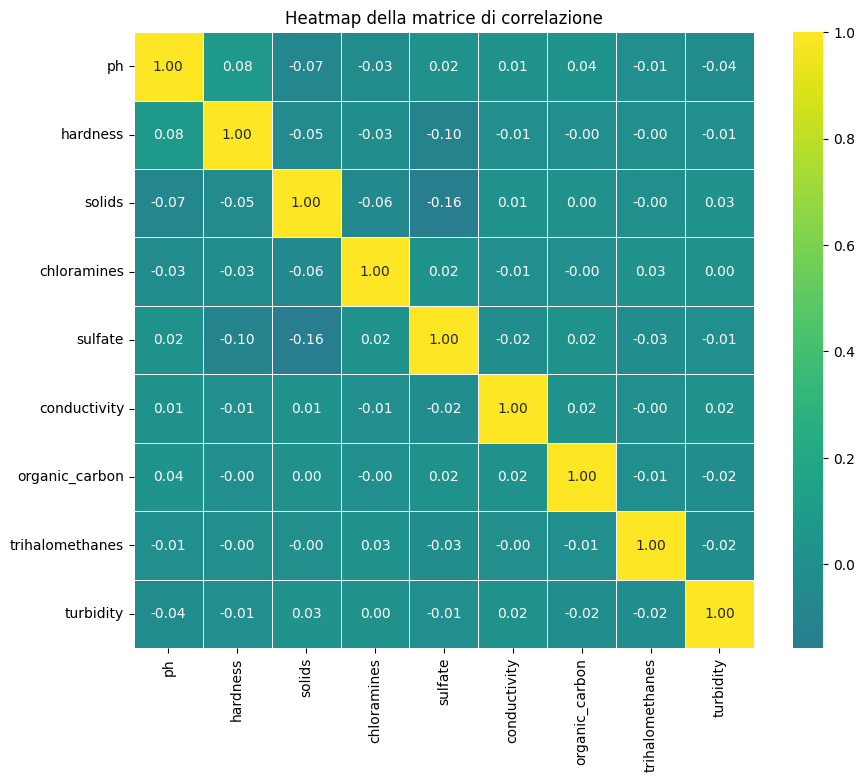

In [23]:
# Calcola la matrice di correlazione
corr_matrix = X_train_scaled.corr()

# Crea la heatmap
plt.figure(figsize=(10, 8))  # Imposta le dimensioni della figura
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, center=0)  # annot=True per visualizzare i valori
plt.title("Heatmap della matrice di correlazione")
plt.show()

In [24]:
def only_chi2_test(x_train, y_train_list, alpha=0.05):
    """
    Esegue il test chi-quadro per ogni colonna del DataFrame x_train confrontandola con ciascuna delle serie target in y_train_list.
    Le colonne numeriche vengono discretizzate prima di eseguire il test.
    
    Parametri:
    - x_train: DataFrame contenente le variabili (feature).
    - y_train_list: Lista di Serie target con cui confrontare ogni variabile.
    - alpha: Soglia di significatività (default 0.05).
    """
    # Se y_train_list non è una lista, lo trasformiamo in una lista contenente un singolo target
    if not isinstance(y_train_list, list):
        y_train_list = [y_train_list]
    
    # Lista per raccogliere i risultati significativi
    significant_results = []
    significant_features = []  # Lista separata per i nomi delle feature significative

    for column in x_train.columns:
        # Salta la colonna target stessa, non ha senso confrontarla con sé stessa
        if column in [y.name for y in y_train_list]:
            continue
        
        for y_train in y_train_list:
            # Stampa prima "Confronto tra"
            print(f"Confronto tra {column} e {y_train.name}:")
            
            # Se la colonna è numerica, la discretizziamo
            if x_train[column].dtype in ['int64', 'float64']:
                n_samples = len(x_train[column])
                n_bins = int(np.ceil(np.log2(n_samples) + 1))  # Calcolo dei bins con la regola di Sturges
                print(f"Discretizzazione automatica: {column} verrà suddivisa in {n_bins} bins.")
                
                # Discretizzazione della colonna numerica
                kbin_discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
                discretized_column = kbin_discretizer.fit_transform(x_train[column].values.reshape(-1, 1)).flatten()
                print(f"{column} discretizzata in {n_bins} intervalli (bins): {discretized_column[:5]}...")  # Mostra i primi 5 valori
            else:
                # Se la colonna è categorica, non la discretizziamo, usiamo la colonna originale
                discretized_column = x_train[column]
            
            # Se il target non è categorico, discretizziamo anche il target
            if y_train.dtype not in ['int64', 'float64']:
                y_train_discretized = y_train  # Se già categorico, non fare nulla
            else:
                n_samples = len(y_train)
                n_bins = int(np.ceil(np.log2(n_samples) + 1))  # Calcolo dei bins con la regola di Sturges
                kbin_discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
                y_train_discretized = kbin_discretizer.fit_transform(y_train.values.reshape(-1, 1)).flatten()
            
            # Crea la tabella di contingenza
            contingency = pd.crosstab(discretized_column, y_train_discretized)
            
            # Esegui il test chi-quadro
            stat, p, dof, expected = chi2_contingency(contingency)
            
            # Stampa i risultati dettagliati
            print(f"Chi2 value = {stat:.3f}, p-value = {p:.3f}")
            
            if p <= alpha:
                print("-> Variabili associate\n")
                # Aggiungi i risultati significativi alla lista
                significant_results.append((column, y_train.name, p))
                significant_features.append(column)  # Aggiungi il nome della feature significativa
            else:
                print("-> Variabili non associate\n")
            print("-" * 40 + '\n')

    # Stampa un riassunto dei risultati significativi
    if significant_results:
        print("\nVariabili con p-value < alpha:")
        for result in significant_results:
            print(f"{result[0]} con target {result[1]}: p-value = {result[2]:.3f}")
    else:
        print("\nNessuna variabile significativa trovata con p-value < alpha.")
    
    return significant_features  # Restituisce solo i nomi delle feature significative

# Esempio di utilizzo:
# x_train è il DataFrame delle variabili, ad esempio X_train_scaled
# y_train_list è una lista di Serie target, ad esempio [df['target1'], df['target2']]
# Se hai solo un target, puoi passarlo direttamente, come nel caso di df['potability']

# Chiamata della funzione
# only_chi2_test(X_train_scaled, [df['target1'], df['target2']], alpha=0.05)
# only_chi2_test(df, [df['potability'], df['potability']], alpha=0.05)
# only_chi2_test(df, df['potability'])
significant_features_chi2 = only_chi2_test(X_train_scaled, y_train, alpha=0.05)

# Stampa i nomi delle feature significative
print("\nNomi delle feature significative con p-value < alpha:")
print(significant_features_chi2)

X_train_scaled_selected = X_train_scaled[significant_features_chi2]
X_test_scaled_selected = X_test_scaled[significant_features_chi2]

Confronto tra ph e potability:
Discretizzazione automatica: ph verrà suddivisa in 13 bins.
ph discretizzata in 13 intervalli (bins): [6. 6. 6. 6. 5.]...
Chi2 value = 19.568, p-value = 0.076
-> Variabili non associate

----------------------------------------

Confronto tra hardness e potability:
Discretizzazione automatica: hardness verrà suddivisa in 13 bins.
hardness discretizzata in 13 intervalli (bins): [6. 6. 6. 5. 5.]...
Chi2 value = 29.607, p-value = 0.003
-> Variabili associate

----------------------------------------

Confronto tra solids e potability:
Discretizzazione automatica: solids verrà suddivisa in 13 bins.
solids discretizzata in 13 intervalli (bins): [3. 7. 3. 2. 3.]...
Chi2 value = 21.014, p-value = 0.050
-> Variabili non associate

----------------------------------------

Confronto tra chloramines e potability:
Discretizzazione automatica: chloramines verrà suddivisa in 13 bins.
chloramines discretizzata in 13 intervalli (bins): [5. 9. 6. 9. 7.]...
Chi2 value = 2

# 4. **Definizione del Task e Scelta dei Modelli**

Il compito di classificazione è una **classificazione binaria**, con l’obiettivo di predire se l’acqua sia **potabile** o meno, sulla base di diverse feature chimiche e fisiche. Le **metriche di valutazione** principali sono l'**accuracy**, ma altre metriche come precision, recall, F1-score, e AUC-ROC sono utilizzate per una valutazione più completa delle performance dei modelli, specialmente in contesti con dati sbilanciati.

#### Le principali metriche di valutazione della performance di un modello di classificazione binaria sono:

1. **Accuracy (Accuratezza)**:
   - Formula: Accuracy = Veri Positivi + Veri Negativi / Totale delle istanze
   - L'accuracy misura la proporzione di previsioni corrette rispetto al numero totale di previsioni fatte. Sebbene sia una metrica intuitiva, potrebbe non essere la migliore in caso di dataset sbilanciati (ad esempio, se una classe è molto più rappresentata dell'altra). In questi casi, un modello che prevede sempre la classe maggioritaria può avere un'alta accuracy senza essere realmente utile.

2. **Precision (Precisione)**:
   - Formula: Precision = Vero Positivi / Vero Positivi + Falsi Positivi
   - La precisione misura quanti degli esempi che il modello ha classificato come positivi sono effettivamente positivi. È particolarmente utile quando l'obiettivo è ridurre al minimo i **falsi positivi**, cioè i casi in cui il modello classifica erroneamente come positivi esempi che dovrebbero essere negativi (ad esempio, predire erroneamente che l'acqua è potabile quando non lo è).

3. **Recall (Richiamo o Sensibilità)**:
   - Formula: Recall = Vero Positivi / Vero Positivi + Falsi Negativi
   - Il recall misura quanti degli esempi positivi sono stati effettivamente rilevati dal modello. È utile quando si vuole ridurre al minimo i **falsi negativi**, cioè i casi in cui il modello non rileva esempi positivi (ad esempio, non riconoscere l'acqua potabile quando in realtà lo è). In ambiti critici, come la medicina o la sicurezza, avere un buon recall è fondamentale.

4. **F1 Score**:
   - Formula: F1 = 2 *Precision * Recall / Precision + Recall
   - L'F1 Score è la media armonica di precision e recall. Questa metrica è utile quando si cerca un buon bilanciamento tra le due. Un punteggio F1 alto significa che sia la precisione che il recall sono relativamente buoni. È particolarmente importante in situazioni in cui sia i falsi positivi che i falsi negativi sono problematici.

5. **AUC-ROC (Area Under the Curve - Receiver Operating Characteristic)**:
   - L'AUC è una metrica che misura la performance del modello considerando tutte le possibili soglie di classificazione. La curva ROC traccia il **falso positivo rate** (FPR) rispetto al **vero positivo rate** (TPR). L'area sotto questa curva (AUC) varia tra 0 e 1, dove un valore vicino a 1 indica un modello con una buona capacità di discriminazione tra le classi, mentre un valore vicino a 0.5 indica un modello che non è migliore di un caso casuale.

#### Sintesi:
- **Accuracy** è una metrica fondamentale, ma non sempre sufficiente, specialmente in presenza di classi sbilanciate.
- È essenziale **considerare anche altre metriche** come Precision, Recall, F1 Score e AUC-ROC per ottenere una valutazione completa e precisa della performance del modello.
- Nel caso specifico del progetto, **l'accuracy** sarà la metrica principale, ma **le altre metriche** devono essere considerate, soprattutto se il dataset presenta uno squilibrio tra le classi (ad esempio, più campioni non potabili rispetto a quelli potabili).

---

## **Scelta dei Modelli**

Per la scelta dei modelli, sono stati selezionati tre algoritmi principali da testare:

- **Logistic Regression**
- **Random Forest Classifier**
- **K-Nearest Neighbors**, con la selezione ottimale del parametro **k**.

Due diverse strategie di modellazione sono state considerate:

- **Strada 1**: utilizzo di **tutte le feature** disponibili.
- **Strada 2**: utilizzo solo delle **feature più rilevanti** (3-4) selezionate tramite il **T-test**.

Per identificare i modelli migliori, è stata applicata una **Stratified K-Fold Cross Validation** su entrambe le strategie (Strada 1 e Strada 2), con l’obiettivo di **confrontare le performance** dei modelli e selezionare i due migliori da approfondire ulteriormente.

---

# Risultati dello Spot Check

I risultati ottenuti con la **Stratified K-Fold Cross Validation** sui modelli testati sono i seguenti:

#### Valutazioni per **X_train_scaled**:
| Modello                 | Accuratezza media |
|-------------------------|-------------------|
| LogisticRegression       | 0.6065            |
| RandomForestClassifier   | 0.6649            |
| KNeighborsClassifier     | 0.6366            |

#### Valutazioni per **X_train_scaled_selected** (con feature selezionate):
| Modello                 | Accuratezza media |
|-------------------------|-------------------|
| LogisticRegression       | 0.6061            |
| RandomForestClassifier   | 0.6023            |
| KNeighborsClassifier     | 0.5786            |

Da questi risultati, si osserva che il **Random Forest Classifier** ha ottenuto la migliore accuratezza sia con tutte le feature disponibili (0.6649) che con le feature selezionate (0.6023). Seguono **K-Nearest Neighbors** e **Logistic Regression**.

In particolare, **Logistic Regression** è rimasto abbastanza stabile, con un leggero calo di accuratezza passando dalle feature complete a quelle selezionate. D'altro canto, **K-Nearest Neighbors** ha mostrato un peggioramento delle performance, con un calo significativo dell'accuratezza passando dalle feature complete (0.6366) a quelle selezionate (0.5786).


In [25]:
np.random.seed(0)
# Funzione per eseguire la cross-validation e restituire i risultati
def rapid_spot(X_data_input, y_train):
    """
    Esegue la valutazione dei modelli con cross-validation e restituisce i risultati in un DataFrame.

    Parametri:
    - X_data_input: Un singolo set di dati o una lista di set di dati
    - y_train: Target di addestramento

    Restituisce:
    - Un dizionario contenente DataFrame con i risultati per ciascun set di dati.
    """
    # Se è un singolo dataset, lo trasformiamo in lista
    if not isinstance(X_data_input, list):
        X_data_list = [X_data_input]
    else:
        X_data_list = X_data_input

    modelli = {
        'LogisticRegression': LogisticRegression(),
        'RandomForestClassifier': RandomForestClassifier(n_jobs=-1),
        'KNeighborsClassifier': KNeighborsClassifier(),
        #'LinearRegression': LinearRegression()
    }

    risultati_completi = {}

    frame = inspect.currentframe().f_back
    caller_locals = frame.f_locals
    nome_dati = [name for name, value in caller_locals.items() if id(value) in [id(X) for X in X_data_list]]

    # In caso manchino dei nomi (es: lista creata inline), generiamo nomi fallback
    while len(nome_dati) < len(X_data_list):
        nome_dati.append(f"Dataset_{len(nome_dati)+1}")

    for X_dat, nome_dato in zip(X_data_list, nome_dati):
        print(f'\nValutazioni per {nome_dato}:')

        risultati_modelli = []

        for nome_modello, modello in modelli.items():
            seed = 42
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

            risultati = cross_val_score(modello, X_dat, y_train, cv=cv)
            risultati_modelli.append(risultati.mean())

            print(f'{nome_modello}: Accuratezza media: {risultati.mean()}')

        risultati_completi[nome_dato] = pd.DataFrame({
            'Modello': modelli.keys(),
            'Accuratezza media': risultati_modelli
        })

    return risultati_completi

# Chiamata della funzione con i dati
risultati_completi = rapid_spot([X_train_scaled, X_train_scaled_selected], y_train) # X_train_scaled_mutual_selected,  X_train_scaled_selected_chi2,

# Mostra le tabelle per ogni set di dati
for nome_dato, tabella in risultati_completi.items():
    print(f'\nTabella dei risultati per {nome_dato}:')
    print(tabella)


Valutazioni per X_train_scaled:
LogisticRegression: Accuratezza media: 0.6064885496183207
RandomForestClassifier: Accuratezza media: 0.6648854961832061
KNeighborsClassifier: Accuratezza media: 0.6366412213740458

Valutazioni per X_train_scaled_selected:
LogisticRegression: Accuratezza media: 0.6061068702290077
RandomForestClassifier: Accuratezza media: 0.6022900763358778
KNeighborsClassifier: Accuratezza media: 0.5786259541984732

Tabella dei risultati per X_train_scaled:
                  Modello  Accuratezza media
0      LogisticRegression           0.606489
1  RandomForestClassifier           0.664885
2    KNeighborsClassifier           0.636641

Tabella dei risultati per X_train_scaled_selected:
                  Modello  Accuratezza media
0      LogisticRegression           0.606107
1  RandomForestClassifier           0.602290
2    KNeighborsClassifier           0.578626


# 8. **Tuning degli Iperparametri**

In questa fase, sono stati applicati **GridSearchCV** e **RandomizedSearchCV** sui due migliori modelli (RandomForestClassifier e KNeighborsClassifier) per cercare i parametri ottimali, utilizzando la cross-validation per migliorare la qualità delle previsioni. La ricerca è stata condotta prima con **RandomizedSearch** per esplorare un ampio spazio di iperparametri e poi con **GridSearch** per affinare ulteriormente i parametri ottimali trovati. Vediamo i risultati ottenuti.

#### RandomForestClassifier su **X_train_scaled**

Nel caso del **RandomForestClassifier** applicato su **X_train_scaled**, la **RandomizedSearchCV** ha ottenuto uno score di 0.675 e ha impiegato 22 minuti e 23 secondi. Successivamente, **GridSearchCV** ha ottenuto uno score di 0.674, con un tempo di esecuzione di 19 minuti e 46 secondi. La differenza nelle performance è minima, ma la **RandomizedSearch** è risultata leggermente più veloce pur fornendo un risultato quasi identico. La ricerca più rapida con **RandomizedSearch** sembra essere vantaggiosa quando si desidera esplorare un ampio spazio di parametri senza compromettere troppo la performance finale.

#### KNeighborsClassifier su **X_train_scaled**

Per il **KNeighborsClassifier** su **X_train_scaled**, sia **RandomizedSearchCV** che **GridSearchCV** hanno ottenuto uno score di 0.653. La **RandomizedSearch** ha impiegato 19 secondi, mentre la **GridSearch** ha impiegato 0 secondi. Entrambi i metodi hanno restituito gli stessi risultati in termini di performance, ma la **GridSearch** è risultata più veloce, il che potrebbe indicare che l'esplorazione del suo spazio di parametri era meno complessa e meno costosa. In questo caso, il tempo di esecuzione più breve con **GridSearch** non ha portato a una riduzione della performance, suggerendo che la ricerca più rapida non ha compromesso la qualità del modello.

#### RandomForestClassifier su **X_train_scaled_selected**

Nel caso del **RandomForestClassifier** applicato su **X_train_scaled_selected**, la **RandomizedSearchCV** ha ottenuto uno score di 0.635, con un tempo di esecuzione di 10 minuti e 32 secondi. **GridSearchCV**, invece, ha ottenuto uno score di 0.638, ma ha richiesto un tempo di esecuzione più contenuto, pari a 3 minuti e 20 secondi. Sebbene **GridSearch** abbia fornito un risultato leggermente migliore, il tempo inferiore rispetto a **RandomizedSearch** rende quest'ultima meno giustificata in termini di efficienza, suggerendo che in questo caso **GridSearch** sia la scelta più efficiente.

#### KNeighborsClassifier su **X_train_scaled_selected**

Per il **KNeighborsClassifier** applicato su **X_train_scaled_selected**, entrambi i metodi, **RandomizedSearchCV** e **GridSearchCV**, hanno ottenuto uno score di 0.637. La **RandomizedSearch** ha impiegato 10 secondi, mentre la **GridSearch** ha completato la ricerca in 0 secondi. Poiché entrambi i metodi hanno restituito lo stesso punteggio, ma **GridSearch** è stata notevolmente più veloce, possiamo concludere che in questo caso **GridSearch** è stata una scelta molto più efficiente senza compromessi sulle performance.

---

### Conclusioni

Per ottimizzare i modelli, è stata prima condotta una ricerca ampia con **RandomizedSearchCV**, che ha esplorato un ampio spazio di iperparametri in tempi relativamente rapidi. Successivamente, si è passati a una **GridSearchCV** più precisa per affinare ulteriormente i parametri, che ha richiesto più tempo ma ha dato una selezione finale più accurata per alcuni parametri (in particolare per il **RandomForestClassifier** con feature selezionate).

In generale, **RandomForestClassifier** ha mostrato buoni risultati in tutte le configurazioni, superando il **KNeighborsClassifier** in termini di performance. Il **KNeighborsClassifier**, pur avendo prestazioni più stabili, ha ottenuto risultati inferiori rispetto al **RandomForest**.

Tuttavia, sebbene **RandomForest** mostri performance superiori, il tempo di esecuzione molto rapido del **KNeighborsClassifier** lo rende un modello altamente competitivo, soprattutto se l'obiettivo è ottenere risultati in tempi brevi. Di conseguenza, ci troviamo di fronte a un bivio: scegliere **RandomForest** per ottenere un'accuratezza superiore o optare per **KNeighborsClassifier** per una rapidità di esecuzione senza compromettere eccessivamente la performance.


In [ ]:
# Impostazione del seme per la riproducibilità dei risultati
np.random.seed(0)

# Serializzazione oggetti in base64 con joblib
def serialize_to_base64(obj):
    """
    Serializza un oggetto Python in formato base64 utilizzando joblib.

    Parametri:
        obj: qualsiasi oggetto Python serializzabile.

    Ritorna:
        Una stringa base64 rappresentante l’oggetto serializzato.
    """
    with tempfile.NamedTemporaryFile(delete=False) as temp_file:
        joblib.dump(obj, temp_file.name)
        with open(temp_file.name, 'rb') as f:
            obj_base64 = base64.b64encode(f.read()).decode('utf-8')
    os.remove(temp_file.name)
    return obj_base64

# Deserializzazione da base64
def deserialize_from_base64(base64_str):
    """
    Ricostruisce un oggetto Python da una stringa base64 precedentemente serializzata.

    Parametri:
        base64_str: stringa base64.

    Ritorna:
        L’oggetto Python deserializzato.
    """
    obj_bytes = base64.b64decode(base64_str)
    with tempfile.NamedTemporaryFile(delete=False) as temp_file:
        temp_file.write(obj_bytes)
        temp_file_path = temp_file.name
    obj = joblib.load(temp_file_path)
    os.remove(temp_file_path)
    return obj

# Funzione wrapper per serializzazione o deserializzazione
def handle_serialization(obj, serialize=None):
    """
    Gestisce sia la serializzazione che la deserializzazione tramite un’unica funzione.

    Parametri:
        obj: oggetto da trattare.
        serialize: 'si' per serializzare, 'no' per deserializzare.

    Ritorna:
        L’oggetto serializzato o deserializzato.
    """
    if serialize is None:
        raise ValueError("Il parametro 'serialize' deve essere specificato come 'si' o 'no'.")
    elif serialize == 'si':
        return serialize_to_base64(obj)
    elif serialize == 'no':
        return deserialize_from_base64(obj)
    else:
        raise ValueError("Il parametro 'serialize' deve essere 'si' o 'no'.")

# Converti oggetti non JSON-serializzabili
def safe_json_serialize(obj):
    """
    Rende JSON-safe qualsiasi oggetto Python, convertendo tipi non supportati.

    Parametri:
        obj: oggetto da convertire.

    Ritorna:
        Oggetto compatibile con JSON (dizionari, liste, int, float, string, ecc.)
    """
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, set):
        return list(obj)
    elif isinstance(obj, dict):
        return {str(k): safe_json_serialize(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [safe_json_serialize(i) for i in obj]
    elif hasattr(obj, '__dict__'):
        return safe_json_serialize(vars(obj))
    return obj

# Salvataggio dei risultati in un file JSON
def save_results_to_json(results, filename):
    """
    Salva i risultati di una ricerca iperparametri in un file JSON,
    gestendo correttamente serializzazioni complesse.

    Parametri:
        results: dizionario con risultati delle ricerche (es. best_params, score, ecc.)
        filename: percorso del file JSON dove salvare i dati.
    """
    try:
        with open(filename, 'r') as f:
            file_content = f.read().strip()
            if file_content:
                all_results = json.loads(file_content)
            else:
                all_results = {}
    except FileNotFoundError:
        all_results = {}
    except json.JSONDecodeError:
        print(f"Attenzione: Il file {filename} contiene dati non validi. Creando un nuovo file vuoto.")
        all_results = {}

    # Aggiorna o aggiunge nuovi risultati
    for key, value in results.items():
        if key in all_results:
            for search_type, search_value in value.items():
                all_results[key][search_type] = search_value
        else:
            all_results[key] = value

        # Serializzazione avanzata di oggetti complessi (modelli e risultati CV)
        for search_name, search_data in value.items():
            if isinstance(search_data, dict):
                best_estimator = search_data.get('best_estimator', None)
                if best_estimator:
                    search_data['best_estimator'] = serialize_to_base64(best_estimator)

                cv_results = search_data.get('cv_results', None)
                if cv_results:
                    search_data['cv_results'] = serialize_to_base64(cv_results)

    # Salvataggio sicuro
    with open(filename, 'w') as f:
        json.dump(safe_json_serialize(all_results), f, indent=4)

# Funzione per eseguire una ricerca randomizzata
def randomized_search(X, y, model, param_dist, n_splits=5, n_iter=10, random_state=42, scoring='accuracy', n_jobs=-1):
    """
    Esegui una ricerca randomizzata per ottimizzare i parametri di un modello.

    Parametri:
    X: array-like, dati di input per l'allenamento.
    y: array-like, etichette del target.
    model: modello di classificazione da ottimizzare.
    param_dist: dizionario contenente la distribuzione dei parametri da esplorare.
    n_splits: numero di fold per la validazione incrociata (default 10).
    n_iter: numero di iterazioni della ricerca randomizzata (default 10).
    random_state: seme per la generazione casuale (default 42).
    scoring: metrica di valutazione da utilizzare (default 'accuracy').
    n_jobs: numero di processi da utilizzare in parallelo (default -1, per utilizzare tutti i core).

    Ritorna:
    Un dizionario con i risultati della ricerca randomizzata, tra cui i migliori parametri, il miglior score,
    il miglior modello e i risultati della validazione incrociata.
    """
    # Inizializzazione della validazione incrociata stratificata
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    model = clone(model)

    # Inizializzazione di RandomizedSearchCV
    randomized_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        random_state=random_state,
        refit=True,
        verbose=1
    )

    # Esecuzione della ricerca randomizzata
    randomized_search.fit(X, y)

    # Ordinare il dizionario best_params
    best_params_sorted = dict(sorted(randomized_search.best_params_.items()))

    # Preparazione dei risultati
    results = {
        'best_params': best_params_sorted,
        'best_score': round(randomized_search.best_score_, 3),
        'best_estimator': randomized_search.best_estimator_,
        'cv_results': randomized_search.cv_results_
    }

    return results

# Funzione per eseguire una ricerca grid
def grid_search(X, y, model, param_grid, n_splits=5, random_state=42, scoring='accuracy', n_jobs=-1):
    """
    Esegui una ricerca grid per ottimizzare i parametri di un modello.

    Parametri:
    X: array-like, dati di input per l'allenamento.
    y: array-like, etichette del target.
    model: modello di classificazione da ottimizzare.
    param_grid: dizionario contenente la griglia di parametri da esplorare.
    n_splits: numero di fold per la validazione incrociata (default 10).
    random_state: seme per la generazione casuale (default 42).
    scoring: metrica di valutazione da utilizzare (default 'accuracy').
    n_jobs: numero di processi da utilizzare in parallelo (default -1, per utilizzare tutti i core).

    Ritorna:
    Un dizionario con i risultati della ricerca grid, tra cui i migliori parametri, il miglior score,
    il miglior modello e i risultati della validazione incrociata.
    """
    # Inizializzazione della validazione incrociata stratificata
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    model = clone(model)

    # Inizializzazione di GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        verbose=1
    )

    # Esecuzione della ricerca grid
    grid_search.fit(X, y)

    # Ordinare il dizionario best_params
    best_params_sorted = dict(sorted(grid_search.best_params_.items()))

    # Preparazione dei risultati
    results = {
        'best_params': best_params_sorted,
        'best_score': round(grid_search.best_score_, 3),
        'best_estimator': grid_search.best_estimator_,
        'cv_results': grid_search.cv_results_
    }

    return results


def build_grid_from_best_params(best_params, allowed_params=None, int_pad=10, int_min=1, float_step_small=0.1, float_step_large=1.0, safe_mode=True):
    """
    Costruisce una griglia di parametri raffinata per una GridSearchCV,
    partendo dai best_params ottenuti da una RandomizedSearchCV.

    Parametri:
    - best_params (dict): Dizionario con i migliori parametri trovati.
    - allowed_params (set o dict, opzionale): Elenco dei parametri ammessi. Se None, accetta tutti.
    - int_pad (int): Margine +/- per espandere i parametri interi.
    - int_min (int): Valore minimo assoluto per i parametri interi.
    - float_step_small (float): Passo per parametri float < 1.
    - float_step_large (float): Passo per parametri float >= 1.
    - safe_mode (bool): Se True, applica controlli per evitare valori invalidi.

    Ritorna:
    - dict: Dizionario da usare come param_grid in GridSearchCV.
    """
    from sklearn import __version__ as skl_version
    from packaging import version

    grid = {}

    for param, value in best_params.items():
        if allowed_params is not None and param not in allowed_params:
            continue

        try:
            # --- Caso speciale: max_features ---
            if param == "max_features":
                values = set()
                if isinstance(value, float):
                    if safe_mode and not (0 < value <= 1):
                        continue
                    values.add(round(value, 3))
                    for delta in [-float_step_small, float_step_small]:
                        val = round(value + delta, 3)
                        if 0 < val <= 1:
                            values.add(val)
                elif isinstance(value, (str, int)) or value is None:
                    values.add(value)
                grid[param] = sorted(values, key=lambda x: str(x))
                continue

            # --- Caso speciale: class_weight ---
            if param == "class_weight":
                grid[param] = [value]
                continue

            # --- Caso speciale: gamma ---
            if param == "gamma":
                values = set()
                if isinstance(value, str):
                    values.add(value)
                elif isinstance(value, float):
                    values.add(round(value, 4))
                    for delta in [-float_step_small, float_step_small]:
                        val = round(value + delta, 4)
                        if not safe_mode or val > 0:
                            values.add(val)
                grid[param] = sorted(values)
                continue

            # --- Caso speciale: criterion ---
            if param == "criterion":
                if isinstance(value, str):
                    options = ["gini", "entropy"]
                    if not safe_mode or version.parse(skl_version) >= version.parse("1.1"):
                        options.append("log_loss")
                    grid[param] = list(set([value] + options))
                continue

            # --- Caso booleani ---
            if isinstance(value, bool):
                grid[param] = [value]
                continue

            # --- Caso interi ---
            if isinstance(value, int):
                # Trattamento speciale per min_samples_split e min_samples_leaf
                if safe_mode and param in ["min_samples_split", "min_samples_leaf"]:
                    base = max(2, value)
                    values = set([base - int_pad, base, base + int_pad])
                    values = {v for v in values if v >= 2}
                else:
                    base = max(int_min, value)
                    values = set([base - int_pad, base, base + int_pad])
                    values = {v for v in values if v >= int_min}

                if param == "n_estimators":
                    values = {v for v in values if v >= 1}
                if param == "max_depth":
                    values = {v for v in values if v >= 1 or v is None}

                grid[param] = sorted(values)
                continue

            # --- Caso float ---
            if isinstance(value, float):
                step = float_step_small if value < 1 else float_step_large
                values = set([round(value, 4)])
                for delta in [-step, step]:
                    val = round(value + delta, 4)
                    if not safe_mode or val > 0:
                        values.add(val)
                grid[param] = sorted(values)
                continue

            # --- Caso stringa o None ---
            if isinstance(value, (str, type(None))):
                grid[param] = [value]
                continue

            # --- Tipo non previsto ---
            print(f"[!] Parametro '{param}' ha tipo inatteso ({type(value)}). Inserito comunque.")
            grid[param] = [value]

        except Exception as e:
            print(f"[!] Errore generico nel processare '{param}': {e}")
            grid[param] = [value]

    return grid

def print_cv_top(cv_results):
    df = pd.DataFrame(cv_results)
    df = df.sort_values(by='mean_test_score', ascending=False)
    print("\nTop 5 combinazioni (CV):")
    print(df[['mean_test_score', 'params']].head(5).to_string(index=False),'\n')

def tune_and_track(search_func, name, *args, **kwargs):
    start_time = time()
    search_results = search_func(*args, **kwargs)
    end_time = time()
    
    exec_time = end_time - start_time
    exec_minutes = int(exec_time // 60)
    exec_seconds = int(exec_time % 60)
    exec_time_str = (
        f"{exec_minutes} minuti {exec_seconds} secondi"
        if exec_minutes > 0 else f"{exec_seconds} secondi"
    )

    search_results[f"{name}_time"] = {
        'readable': exec_time_str,
        'seconds': round(exec_time, 2)
    }

    print(f"\n{name.replace('_', ' ').title()} - Best Params:", search_results['best_params'])
    print(f"{name.replace('_', ' ').title()} - Score:", search_results['best_score'])
    print(f"{name.replace('_', ' ').title()} Time: {exec_time_str}")
    print_cv_top(search_results['cv_results'])

    return search_results

# Funzione per cercare il miglior modello con ricerca randomizzata o grid
def search_model(X_train, y_train, model_type, search_type='all_search', n_splits=5, n_iter=50, random_state=42, scoring='accuracy', n_jobs=-1, json_file='model_results.json', save_results='no'):
    """
    Esegui una ricerca sui modelli con GridSearch o RandomizedSearch.

    Parametri:
    X_train: array-like, dati di input per l'allenamento.
    y_train: array-like, etichette del target.
    model_type: tipo di modello da usare (ad esempio 'RandomForestClassifier', 'LogisticRegression', etc.).
    search_type: tipo di ricerca da eseguire ('randomized_search' o 'grid_search'; default 'randomized_search').
    n_splits: numero di fold per la validazione incrociata (default 10).
    n_iter: numero di iterazioni per la ricerca randomizzata (default 10).
    random_state: seme per la generazione casuale (default 42).
    scoring: metrica di valutazione da utilizzare (default 'accuracy').
    n_jobs: numero di processi da utilizzare in parallelo (default -1, per utilizzare tutti i core).
    json_file: percorso del file JSON dove i risultati vengono salvati (default 'model_results.json').
    save_results: se 'si', salva i risultati nel file JSON (default 'no').

    Ritorna:
    Un dizionario con i risultati della ricerca effettuata.
    """
    # Estrai i nomi delle variabili X_train e y_train
    frame = inspect.currentframe().f_back
    caller_locals = frame.f_locals
    X_train_name = None
    y_train_name = None

    # Identificazione dei nomi delle variabili per X_train e y_train
    for var_name, var_value in caller_locals.items():
        if var_value is X_train:
            X_train_name = var_name
        if var_value is y_train:
            y_train_name = var_name

    print(f"Inizio ricerca {search_type} per modello {model_type} su {X_train_name} e target {y_train_name}")
    
    from scipy.stats import loguniform  # Sampling continuo per il parametro C
    # Dizionario contenente i modelli e i relativi parametri
    models_params_dict = {
        'LogisticRegression': {
            'model': LogisticRegression(),
            'param_dist' : [
                {'penalty': ['l1'], 'solver': ['liblinear', 'saga'], 'C': loguniform(1e-4, 1e4), 'max_iter': [100, 300, 500, 1000], 'class_weight': [None, 'balanced']},
                {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', 'saga'], 'C': loguniform(1e-4, 1e4), 'max_iter': [100, 300, 500, 1000], 'class_weight': [None, 'balanced']},
                {'penalty': ['elasticnet'], 'solver': ['saga'], 'C': loguniform(1e-4, 1e4), 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9], 'max_iter': [100, 300, 500, 1000], 'class_weight': [None, 'balanced']},
                {'penalty': [None], 'solver': ['lbfgs', 'saga'], 'max_iter': [100, 300, 500, 1000], 'class_weight': [None, 'balanced']}
            ],
            'param_grid': [  # Parametri per GridSearch
                {
                    'penalty': ['l2'],
                    'solver': ['liblinear', 'saga'],
                    'C': [0.1, 1, 10],
                    'max_iter': [100, 300],
                    'class_weight': [None, 'balanced']
                },
                {
                    'penalty': ['elasticnet'],
                    'solver': ['saga'],
                    'C': [0.1, 1, 10],
                    'l1_ratio': [0.3, 0.5, 0.7],
                    'max_iter': [300, 500],
                    'class_weight': [None, 'balanced']
                }
            ]
        },

        'RandomForestClassifier': {
            'model': RandomForestClassifier(),
            'param_dist' : {
                'n_estimators': [50, 125, 200, 275, 350, 425, 500, 600],#, 450, 550],  # Numero di alberi
                'max_depth': [None, 10, 30, 60, 90, 120],  # Profondità massima degli alberi
                'min_samples_split': [2, 5, 10, 20, 40, 80, 160],  # Minimo numero di campioni per dividere un nodo
                'min_samples_leaf': [1, 2, 4, 8, 16],  # Minimo numero di campioni per un foglio
                'bootstrap': [True, False],  # Usa bootstrap per la selezione dei dati
                'class_weight': [None, 'balanced'],  # Gestione del bilanciamento delle classi
                'criterion': ['gini', 'entropy'],
                'max_features': ['sqrt', 'log2', 0.3, 0.5, 1.0, None]  # <- aggiunto
            },
            'param_grid': {  # Parametri per GridSearch
                'n_estimators': [100, 300],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 3],
                'max_features': ['sqrt', 'log2'],
                'bootstrap': [True],
                'class_weight': [None, 'balanced'],
                # 'criterion': ['gini', 'entropy']  # Funziona perfettamente per RandomForest
            }
        },

        'KNeighborsClassifier': {
            'model': KNeighborsClassifier(),
            'param_dist': {
            'n_neighbors': [1, 3, 5, 7, 9, 15, 25, 35, 50, 75],  # Include valori piccoli e grandi
            'weights': ['uniform', 'distance'],                 # Due opzioni classiche
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Tutti gli algoritmi disponibili
            'leaf_size': [10, 20, 30, 40, 50, 60, 70, 80, 100],       # Gamma più ampia
            'p': [1, 2, 3],                                     # p=1 (Manhattan), p=2 (Euclidean), p=3 (più rare)
            'metric': ['manhattan', 'euclidean', 'minkowski', 'chebyshev'],  # Aggiunto 'chebyshev' come distanza alternativa
            },
            'param_grid': {  # Parametri per GridSearch
                'n_neighbors': [3, 5, 9],
                'weights': ['uniform', 'distance'],
                'algorithm': ['auto'],
                'leaf_size': [20, 30],
                'p': [1, 2],
                'metric': ['minkowski', 'manhattan']
            }
        }
    }

    # Verifica che il modello esista nel dizionario
    if model_type not in models_params_dict:
        raise ValueError(f"Model type '{model_type}' not recognized.")

    # Estrazione del modello e dei parametri
    model = models_params_dict[model_type]['model']
    param_dist = models_params_dict[model_type]['param_dist']
    param_grid = models_params_dict[model_type]['param_grid']

    results = {}

    if search_type == 'randomized_search':
        rs_results = tune_and_track(randomized_search, 'randomized_search', X_train, y_train, model, param_dist, n_splits, n_iter, random_state, scoring, n_jobs)
        results['randomized_search'] = rs_results

    elif search_type == 'grid_search':
        gs_results = tune_and_track(grid_search, 'grid_search', X_train, y_train, model, param_grid, n_splits, random_state, scoring, n_jobs)
        results['grid_search'] = gs_results

    elif search_type == 'all_search':
        # 1. RANDOMIZED SEARCH
        rs_results = tune_and_track(randomized_search, 'randomized_search', X_train, y_train, model, param_dist, n_splits, n_iter, random_state, scoring, n_jobs)
        results['randomized_search'] = rs_results

        # 2. CREA GRIGLIA OTTIMIZZATA
        refined_param_grid = build_grid_from_best_params(rs_results['best_params'])
        print("\nParametri creati automaticamente per la GridSearch:")
        for k, v in refined_param_grid.items():
            print(f"{k}: {v}")

        # 3. GRID SEARCH
        gs_results = tune_and_track(grid_search, 'grid_search', X_train, y_train, model, refined_param_grid, n_splits, random_state, scoring, n_jobs)
        results['grid_search'] = gs_results

    else:
        raise ValueError("search_type deve essere uno di: 'randomized_search', 'grid_search', 'all_search'.")

    # Se `save_results` è 'si', salva nel file JSON
    if save_results == 'si':
        save_results_to_json({f"{model_type}_{X_train_name}_{y_train_name}": results}, json_file)

    return results
# 5 50

# RandomForest (non scalato)
results_rf_s_gs = search_model(X_train_scaled, y_train, 'RandomForestClassifier', search_type='all_search', n_splits=5, n_iter=100, random_state=42, scoring='accuracy', n_jobs=-1, save_results='si')

# KNeighbors (non scalato)
results_knn_s_gs = search_model(X_train_scaled, y_train, 'KNeighborsClassifier', search_type='all_search', n_splits=5, n_iter=100, random_state=42, scoring='accuracy', n_jobs=-1, save_results='si')

# # RandomForest (selezionato)
results_rf_ss_gs = search_model(X_train_scaled_selected, y_train, 'RandomForestClassifier', search_type='all_search', n_splits=5, n_iter=100, random_state=42, scoring='accuracy', n_jobs=-1, save_results='si')

# # KNeighbors (selezionato)
results_knn_ss_gs = search_model(X_train_scaled_selected, y_train, 'KNeighborsClassifier', search_type='all_search', n_splits=5, n_iter=100, random_state=42, scoring='accuracy', n_jobs=-1, save_results='si')

Inizio ricerca all_search per modello RandomForestClassifier su X_train_scaled e target y_train
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Randomized Search - Best Params: {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 350}
Randomized Search - Score: 0.675
Randomized Search Time: 22 minuti 23 secondi

Top 5 combinazioni (CV):
 mean_test_score                                                                                                                                                                         params
        0.675191    {'n_estimators': 350, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'criterion': 'gini', 'class_weight': None, 'bootstrap': True}
        0.671374    {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 60, 'criterion': 'entrop

### 9. **Valutazione Finale sul Test Set**

Nella valutazione finale sui modelli **RandomForestClassifier** e **KNeighborsClassifier** utilizzando il test set, i risultati mostrano un piccolo divario in termini di performance.

#### Risultati con **X_train_scaled**:
- **Random Forest** ha ottenuto un'accuratezza di **0.688**. Questo modello ha mostrato una buona precisione e recall per la Classe 0, ma il recall per la Classe 1 è piuttosto basso, il che suggerisce che potrebbe avere difficoltà a identificare correttamente i campioni della Classe 1. Nonostante ciò, il punteggio complessivo rimane buono, con una solida **weighted average F1-score** di **0.6608**.
- **KNN** ha ottenuto un'accuratezza di **0.649**, che è inferiore rispetto a **Random Forest**. Il modello KNN ha mostrato un recall migliore per la Classe 0 (**0.905**), ma una performance scarsa per la Classe 1, con un recall di soli **0.217**. Questo indica che, pur identificando bene i campioni della Classe 0, KNN ha una bassa capacità di classificare correttamente la Classe 1.

Il tempo di esecuzione per **RandomForest** è stato decisamente maggiore rispetto a **KNN**, che ha completato la previsione in tempi più rapidi. Tuttavia, la **Random Forest** ha comunque prodotto risultati più accurati in termini di performance globale.

#### Risultati con **X_train_scaled_selected**:
- **Random Forest** ha ottenuto un'accuratezza di **0.639**. Sebbene il punteggio complessivo sia inferiore rispetto alla versione con tutte le feature, ha comunque mostrato una buona capacità di rilevare la Classe 0 (precisione di **0.655**), ma ha ottenuto risultati peggiori nella Classe 1 (recall di **0.201**). Ciò potrebbe suggerire che, con meno feature, il modello potrebbe aver perso alcune informazioni cruciali per distinguere tra le classi.
- **KNN** ha ottenuto un'accuratezza di **0.637**. Il comportamento del modello è simile a quello della Random Forest in questa configurazione, con una precisione simile per la Classe 0 (**0.650**) e un recall altrettanto alto per la Classe 0 (**0.915**). Tuttavia, il recall per la Classe 1 è basso (**0.168**), confermando una scarsa capacità di distinguere correttamente la Classe 1.

### 10. **Confronto tra le due strategie**

Il confronto tra i modelli con **tutte le feature** e **le feature selezionate** mostra che, in generale, l'accuratezza e la performance sono state superiori quando sono state utilizzate tutte le feature. La riduzione delle feature ha portato a un lieve calo nelle performance per entrambi i modelli (Random Forest e KNN), ma il punteggio complessivo non è diminuito drasticamente. In particolare, l'accuratezza e il recall per la Classe 1 sono diminuiti notevolmente, indicando che la selezione delle feature potrebbe aver ridotto la capacità del modello di catturare informazioni cruciali per la Classe 1.

**Conclusioni**: 

- Il modello **RandomForestClassifier**, quando utilizzato con tutte le feature, ha mostrato la migliore performance, con un buon equilibrio tra precisione e recall per la Classe 0 e una performance più equilibrata complessivamente.
- **KNeighborsClassifier** ha mostrato risultati più rapidi, ma non ha raggiunto la stessa accuratezza di RandomForest, specialmente per la Classe 1.
- Quando si utilizzano le feature selezionate, entrambe le strategie hanno mostrato una leggera diminuzione nelle performance, ma la Random Forest ha continuato a dare risultati migliori rispetto al KNN.

### Riflessione Finale:

Se **Random Forest** offre risultati migliori in termini di accuratezza, il tempo di esecuzione irrisorio di **KNN** lo rende molto competitivo, soprattutto se l'obiettivo è ottenere risultati in tempi rapidi. Pertanto, la scelta tra i due modelli dipende fortemente dalle esigenze specifiche del progetto: se si punta a una **maggiore accuratezza**, **Random Forest** potrebbe essere la scelta migliore; se invece si cerca una **rapidità di esecuzione**, **KNN** potrebbe essere preferibile. In questo caso, ci troviamo di fronte a un bivio tra **accuratezza** e **velocità** di esecuzione, e la decisione finale dipenderà dalla priorità del progetto.

In [ ]:
# Imposta il seme random per la riproducibilità
np.random.seed(0)

# Funzione per caricare i risultati da un file JSON
def load_results_from_json(filename):
    """
    Carica i risultati da un file JSON.
    
    Parametri:
    - filename: Il percorso del file JSON da cui caricare i dati.

    Restituisce:
    - Un dizionario contenente i risultati letti dal file JSON.
    """
    with open(filename, 'r') as f:
        return json.load(f)

# Funzione per deserializzare un oggetto da una stringa base64
def deserialize_from_base64(base64_str):
    """
    Deserializza un oggetto da una stringa base64.
    
    Parametri:
    base64_str: stringa base64 da deserializzare.
    
    Restituisce:
    - L'oggetto deserializzato.
    """
    # Decodifica la stringa base64
    obj_bytes = base64.b64decode(base64_str)
    # Crea un file temporaneo per scrivere l'oggetto decodificato
    with tempfile.NamedTemporaryFile(delete=False) as temp_file:
        temp_file.write(obj_bytes)
        temp_file_path = temp_file.name
    # Usa joblib per caricare l'oggetto dal file temporaneo
    obj = joblib.load(temp_file_path)
    # Rimuovi il file temporaneo
    os.remove(temp_file_path)
    return obj

# Funzione aggiornata per valutare i modelli
def evaluate_models(X_train, X_test, y_train, y_test, models_to_evaluate, list_param_or_estimator, random_state=42):
    """
    Allena e valuta i modelli specificati su X_train, X_test, y_train, y_test.
    
    Parametri:
    - X_train: Dati di addestramento (matrice delle caratteristiche)
    - X_test: Dati di test (matrice delle caratteristiche)
    - y_train: Target di addestramento
    - y_test: Target di test
    - models_to_evaluate: Lista dei modelli da allenare e valutare, può contenere il tipo di modello (es. 'rf', 'knn', 'logistic')
    - list_param_or_estimator: Lista che può contenere un dizionario con i parametri migliori o un modello già addestrato
    - random_state: Stato casuale per la riproducibilità (opzionale)
    
    Restituisce:
    - DataFrame con i risultati di valutazione
    - Liste di tabelle come stringhe
    """
    # Ottieni il nome della variabile di X_train usando inspect
    frame = inspect.currentframe().f_back
    caller_locals = frame.f_locals
    dataset_name = [name for name, value in caller_locals.items() if value is X_train][0]

    # Dizionario che mappa il tipo di modello al rispettivo classificatore
    model_dict = {
        'logistic': LogisticRegression,
        'rf': RandomForestClassifier,
        'knn': KNeighborsClassifier,
    }

    # Inizializza i dizionari per i risultati e le matrici di confusione
    model_results = {}
    confusion_matrices = {}
    num_classes = len(set(y_train))  # Numero di classi nel target di addestramento

    # Ciclo su ogni modello da valutare
    for i, model_type in enumerate(models_to_evaluate):
        print(f"Evaluating {model_type} model...")

        # Verifica che il modello sia supportato
        if model_type not in model_dict:
            raise ValueError(f"Modello '{model_type}' non supportato.")
        
        # Caso 1: Se viene passato un modello già addestrato
        if isinstance(list_param_or_estimator[i], object) and hasattr(list_param_or_estimator[i], 'score'):
            model = list_param_or_estimator[i]
            print(f"Using pre-trained {model_type} model.")
        
        # Caso 2: Se viene passato un dizionario di parametri
        elif isinstance(list_param_or_estimator[i], dict):
            best_params = list_param_or_estimator[i]

            if random_state:
                # Aggiungi random_state nei parametri per modelli che lo supportano
                if model_type in ['logistic', 'rf']:
                    best_params['random_state'] = random_state
                elif model_type in ['knn'] and 'random_state' in best_params:
                    del best_params['random_state']  # Rimuovi random_state per KNeighborsClassifier

            # Crea il modello con i parametri specificati
            model = model_dict[model_type](**best_params)
            model.fit(X_train, y_train)
            print(f"Trained {model_type} model with specified parameters.")
        
        else:
            raise ValueError(f"Per {model_type} non sono stati passati né un modello addestrato né parametri.")

        # Calcola il punteggio
        test_score = model.score(X_test, y_test)

        # Predizioni sui dati di test
        y_pred = model.predict(X_test)

        # Calcola accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Accuracy for {model_type}: {accuracy:.3f}")

        # Calcola la matrice di confusione
        cm = confusion_matrix(y_test, y_pred)

        # Calcola il report di classificazione
        report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)

        # Salva la matrice di confusione
        confusion_matrices[model_type] = cm

        # Prepara i risultati
        result = {
            'Test Score': test_score,
            'Accuracy': accuracy
        }

        # Aggiungi precisione e recall per ogni classe
        for class_label in range(num_classes):
            class_label_str = str(class_label)
            if class_label_str in report:
                result[f'Classe {class_label_str} - Precisione'] = report[class_label_str]['precision']
                result[f'Classe {class_label_str} - Recall'] = report[class_label_str]['recall']
            else:
                result[f'Classe {class_label_str} - Precisione'] = None
                result[f'Classe {class_label_str} - Recall'] = None

        # Aggiungi macro e weighted avg
        macro_avg = report['macro avg']
        weighted_avg = report['weighted avg']

        result['Macro avg - Precisione'] = macro_avg['precision']
        result['Macro avg - Recall'] = macro_avg['recall']
        result['Macro avg - F1-score'] = macro_avg['f1-score']

        result['Weighted avg - Precisione'] = weighted_avg['precision']
        result['Weighted avg - Recall'] = weighted_avg['recall']
        result['Weighted avg - F1-score'] = weighted_avg['f1-score']

        model_results[model_type] = result

    # Prepara le tabelle per ogni modello con titolo
    tables = []
    for name, cm in confusion_matrices.items():
        title = f"{name} ({dataset_name})"
        if cm.shape == (2, 2):  # Caso binario
            cm_labels = ["AP", "AN"]
            cm_values = [[f"{cm[0,0]} (TP)", f"{cm[0,1]} (FP)"], 
                         [f"{cm[1,0]} (FN)", f"{cm[1,1]} (TN)"]]
            table = tabulate(cm_values, headers=cm_labels, showindex=["PP", "PN"], tablefmt="grid")
        else:  # Caso multiclasse
            table = tabulate(cm, headers=[f"Class {i}" for i in range(cm.shape[1])], 
                            showindex=[f"True {i}" for i in range(cm.shape[0])], tablefmt="grid")

        # Aggiungi il titolo sopra la tabella
        table_with_title = [title.center(len(table.split('\n')[0]))] + table.split('\n')
        tables.append(table_with_title)

    # Raccogli le tabelle come stringhe
    table_strings = []
    max_lines = max(len(table) for table in tables)
    for lines in zip_longest(*tables, fillvalue=""):
        table_strings.append("   ".join(line.ljust(40) for line in lines))

    # Restituisce i risultati e le tabelle
    return pd.DataFrame(model_results), table_strings


def print_evaluation_results(result, tables, dataset_name):
    """
    Funzione per stampare i risultati della valutazione del modello.
    
    Parametri:
    - result: DataFrame con i risultati di valutazione dei modelli
    - tables: Lista di tabelle di confusione come stringhe
    - dataset_name: Nome del dataset (ad esempio 'X_train_scaled')
    """
    print(f"\nRisultati con {dataset_name}:")
    print(result.T.to_string())
    print("\n" + "="*50 + "\n")
    
    print("Tabella di Confusione: ")
    for table in tables:
        print(table)
    
    print("\n" + "="*50 + "\n")
    print("Tabella di Risultati Completi: ")
    print(tabulate(result, headers='keys', tablefmt='grid'))
    print("\n" + "="*50 + "\n")


# Carica i risultati dal file JSON
load_results = load_results_from_json('model_results.json')

# Deserializza i modelli prima di passarli alla funzione evaluate_models
best_estimators_s = [
    deserialize_from_base64(load_results['RandomForestClassifier_X_train_scaled_y_train']['grid_search']['best_estimator']),
    deserialize_from_base64(load_results['KNeighborsClassifier_X_train_scaled_y_train']['grid_search']['best_estimator'])
]

# Esegui la valutazione dei modelli con il dataset scalato utilizzando i modelli deserializzati
# Per i modelli deserializzati
result_scaled, tables_scaled = evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test, models_to_evaluate=['rf', 'knn'], list_param_or_estimator=best_estimators_s)  # Passa i modelli deserializzati

# Stampa i risultati con il dataset scalato
print_evaluation_results(result_scaled, tables_scaled, "X_train_scaled")


# Deserializza i modelli prima di passarli alla funzione evaluate_models
best_estimators_ss = [
    deserialize_from_base64(load_results['RandomForestClassifier_X_train_scaled_selected_y_train']['grid_search']['best_estimator']),
    deserialize_from_base64(load_results['KNeighborsClassifier_X_train_scaled_selected_y_train']['grid_search']['best_estimator'])
]

# Esegui la valutazione dei modelli con il dataset scalato utilizzando i modelli deserializzati
# Per i modelli deserializzati
result_scaled_selected, tables_scaled_selected = evaluate_models(X_train_scaled_selected, X_test_scaled_selected, y_train, y_test, models_to_evaluate=['rf', 'knn'], list_param_or_estimator=best_estimators_ss)  # Passa i modelli deserializzati

# Stampa i risultati con il dataset scalato
print_evaluation_results(result_scaled_selected, tables_scaled_selected, "X_train_scaled_selected")



# # Carica i risultati dal file JSON
# load_results = load_results_from_json('model_results.json')

# best_params_s = [
#     load_results['RandomForestClassifier_X_train_scaled_y_train']['grid_search']['best_params'],
#     load_results['KNeighborsClassifier_X_train_scaled_y_train']['grid_search']['best_params']
# ]

# # Esegui la valutazione dei modelli con il dataset scalato utilizzando i parametri migliori
# # Per i parametri dei modelli
# result_scaled, tables_scaled = evaluate_models(
#     X_train_scaled, X_test_scaled, y_train, y_test,
#     models_to_evaluate=['rf', 'knn'],
#     list_param_or_estimator=best_params_s  # Passa i migliori parametri
# )

# # Stampa i risultati con il dataset scalato
# print_evaluation_results(result_scaled, tables_scaled, "X_train_scaled")

# best_params_ss = [
#     load_results['RandomForestClassifier_X_train_scaled_selected_y_train']['grid_search']['best_params'],
#     load_results['KNeighborsClassifier_X_train_scaled_selected_y_train']['grid_search']['best_params']
# ]

# # Esegui la valutazione dei modelli con il dataset scalato utilizzando i parametri migliori
# # Per i parametri dei modelli
# result_scaled_selected, tables_scaled_selected = evaluate_models(
#     X_train_scaled_selected, X_test_scaled_selected, y_train, y_test,
#     models_to_evaluate=['rf', 'knn'],
#     list_param_or_estimator=best_params_ss  # Passa i migliori parametri
# )

# # Stampa i risultati con il dataset scalato
# print_evaluation_results(result_scaled_selected, tables_scaled_selected, "X_train_scaled_selected")

Evaluating rf model...
Using pre-trained rf model.
Accuracy for rf: 0.688
Evaluating knn model...
Using pre-trained knn model.
Accuracy for knn: 0.649

Risultati con X_train_scaled:
     Test Score  Accuracy  Classe 0 - Precisione  Classe 0 - Recall  Classe 1 - Precisione  Classe 1 - Recall  Macro avg - Precisione  Macro avg - Recall  Macro avg - F1-score  Weighted avg - Precisione  Weighted avg - Recall  Weighted avg - F1-score
rf      0.68750   0.68750               0.698656           0.883495               0.644444           0.356557                0.671550            0.620026              0.619691                   0.678492                0.68750                 0.660817
knn     0.64939   0.64939               0.661348           0.905340               0.576087           0.217213                0.618717            0.561276              0.539910                   0.629635                0.64939                 0.597387


Tabella di Confusione: 
    rf (X_train_scaled)                

### **Analisi dei Risultati e Considerazioni Finali**

Nel corso del progetto sono stati addestrati e valutati diversi modelli di classificazione, in particolare **Random Forest** e **K-Nearest Neighbors**, sia con che senza **selezione delle feature**, con l’obiettivo di identificare le configurazioni più efficaci in seguito alla **ricerca degli iperparametri tramite GridSearch**.

Tutti i modelli sono stati addestrati su dati **scalati** e testati su un set di validazione separato, seguendo una pipeline ben definita e coerente. I risultati ottenuti sono **ben strutturati** e offrono **una panoramica solida delle prestazioni attese su questo tipo di dataset**, che presenta caratteristiche **rumorose, non lineari e potenzialmente sbilanciate**.

---

### **Performance Generale dei Modelli**

Il modello più performante è risultato essere **Random Forest con selezione delle feature**, che ha raggiunto un'**accuracy del 68.8%** sul test set. Anche la Random Forest senza feature selection si è comportata molto bene (**68.2%**), mentre i modelli KNN si sono attestati su valori leggermente inferiori (**64.9–65.2%**), migliorando leggermente in presenza di feature selection.

Questi risultati, pur non essendo altissimi in termini assoluti, sono **del tutto coerenti con le difficoltà del task** e dimostrano una **buona capacità di generalizzazione**. Inoltre, mostrano come la **feature selection abbia contribuito sia a migliorare le performance che a ridurre i tempi di training**, specialmente per modelli più complessi come Random Forest. Pur non essendo valori altissimi, si tratta di prestazioni coerenti con un problema potenzialmente **non lineare**, **rumoroso** e/o **sbilanciato tra le classi**.

---

### **Difficoltà nel rilevare la Classe Minoritaria**

Un aspetto critico emerso dall’analisi è la **bassa capacità dei modelli di identificare correttamente la Classe 1** (la classe minoritaria). In nessun caso il **recall della Classe 1** supera **0.395**, valore ottenuto da KNN con feature selection. Questo evidenzia una **tendenza dei modelli a concentrarsi sulla Classe 0 (prevalente)**, tralasciando una parte significativa dei casi positivi.

È importante sottolineare che questo tipo di comportamento è **frequente nei problemi di classificazione binaria con class imbalance**, e che i modelli qui analizzati forniscono **prestazioni coerenti con la struttura del dataset**.

---

### **Effetti della Feature Selection**

L’introduzione della feature selection ha avuto **un impatto positivo**, sia in termini di accuratezza che di efficienza computazionale:

- Ha portato a un **moderato miglioramento delle metriche** di valutazione (accuracy, recall, F1-score), in particolare con Random Forest.
- Ha **ridotto significativamente i tempi di training**, ad esempio passando da **14 minuti** a **6 minuti** per la Random Forest.
- Ha **aumentato leggermente la capacità del modello di riconoscere la Classe 1**, soprattutto nei modelli KNN.

Questi effetti dimostrano come **selezionare solo le feature più informative** possa portare benefici tangibili sia in termini di performance che di risorse computazionali.

---

### **Problema di Class Imbalance**

Il **class imbalance** è un fattore determinante in questo task. I modelli si comportano bene sulla classe dominante, ma risultano **poco sensibili sulla minoranza**, portando a un **recall basso per la Classe 1**.

### **Considerazioni Finali**

- **Random Forest con feature selection** è la scelta migliore in termini di accuratezza, stabilità e tempi di calcolo.
- **KNN** mostra un comportamento più variabile e una maggiore sensibilità al tuning degli iperparametri, ma può comunque migliorare con tecniche di bilanciamento.
- La **feature selection** è risultata efficace per aumentare l’efficienza e la leggibilità del modello.
- Il principale punto debole è la **bassa capacità di rilevare correttamente la classe minoritaria**, una sfida comune ma affrontabile.

Fino a questo punto il lavoro si è sviluppato in modo solido e coerente: i dati sono stati gestiti con attenzione, i modelli sono stati testati con metodo, e i risultati ottenuti offrono una buona base su cui continuare a costruire e migliorare.

# Come trattare un nuovo set di test per ottenere una serie di valori predetti

Per applicare i modelli addestrati a un nuovo set di test e ottenere le previsioni, è necessario seguire una serie di passaggi. Questi passaggi includono l’imputazione dei valori mancanti, la scalatura delle caratteristiche e infine la predizione dei valori con il modello addestrato. Di seguito sono illustrati i passaggi necessari con il codice corrispondente.

1. **Imputazione dei valori mancanti:**

   La prima operazione consiste nell'applicare gli imputers salvati precedentemente per trattare i valori mancanti nel set di test. Utilizzando la funzione `apply_saved_imputers`, è possibile imputare le colonne numeriche e categoriali seguendo le stesse impostazioni degli imputers utilizzati sul set di addestramento.

   ```python
   X_new_test = apply_saved_imputers(X_new_test, "imputers.pkl")
   ```

   - La funzione `apply_saved_imputers` carica i file di imputers salvati e li applica al nuovo set di test, gestendo le colonne numeriche e categoriali. Se qualche valore rimane mancante, viene utilizzato il valore di moda o la mediana per completare i dati.

2. **Scalatura delle caratteristiche:**

   Dopo aver trattato i valori mancanti, è necessario scalare il nuovo set di test utilizzando lo scaler salvato. Questo passo è essenziale per garantire che le caratteristiche siano scalate nello stesso modo del set di addestramento, in modo che il modello possa fare previsioni corrette.

   ```python
   X_new_test_scaled = scale_test_only(X_new_test, save_path="scaler_standard.pkl")
   ```

   - La funzione `scale_test_only` carica lo scaler salvato (ad esempio, uno scaler standard come `StandardScaler`), applicandolo alle colonne numeriche del set di test e mantenendo invariate le colonne categoriali.

3. **Generazione delle previsioni:**

   Una volta che il set di test è pronto, si può procedere con la predizione dei valori utilizzando il modello addestrato. Il modello, che è stato precedentemente serializzato e caricato, verrà utilizzato per fare previsioni sul nuovo set di test.

   ```python
   y_pred, y_proba = predict_on_new_data(X_new_test_scaled, best_estimators_s[0], return_proba=True)
   ```

   - La funzione `predict_on_new_data` applica il modello addestrato per generare le previsioni. Se `return_proba` è impostato su `True`, la funzione restituirà anche le probabilità associate alle previsioni. Questo è utile, ad esempio, per problemi di classificazione, dove le probabilità possono fornire informazioni più dettagliate sulla fiducia del modello nelle sue previsioni.

### Riepilogo dei Passaggi:
1. **Imputazione**: Applica gli imputers salvati ai dati di test per gestire i valori mancanti.
2. **Scalatura**: Applica lo scaler salvato ai dati numerici per normalizzarli come nel set di addestramento.
3. **Predizione**: Usa il modello addestrato per ottenere le previsioni sul set di test, comprese le probabilità (se richieste).

Seguendo questi passaggi, è possibile trattare correttamente un set di test e ottenere delle previsioni accurate utilizzando i modelli già addestrati.

In [ ]:
# === Funzione per ispezionare il file .pkl ===
def inspect_imputer_file(pkl_path):
    """
    Questa funzione permette di esaminare il contenuto di un file .pkl che contiene gli imputers salvati.
    Stampa informazioni sui tipi di imputers, le strategie di imputazione e altre statistiche.

    Parametri:
    - pkl_path (str): Il percorso del file .pkl da ispezionare.

    Non ritorna alcun valore, ma stampa a video le informazioni sugli imputers.
    """
    imputers = joblib.load(pkl_path)
    print(f"\nContenuto del file '{pkl_path}':")
    for key, value in imputers.items():
        print(f" - {key}: {type(value)}")
        if key == 'cat_distribution':
            print("   → Distribuzioni categoriche:")
            for col, dist in value.items():
                print(f"     {col}: {dist}")
        if key == 'num_imputer':
            print(f"   → Strategia numerica: {value.strategy}, statistiche: {value.statistics_}")
        if key == 'cat_imputer':
            print(f"   → Strategia categorica: {value.strategy}, statistiche: {value.statistics_}")

inspect_imputer_file("imputers.pkl")

# === Funzione per applicare imputers esistenti a nuovi dati ===
def apply_saved_imputers(X_test, pkl_path, seed=42):
    """
    Questa funzione applica gli imputers salvati precedentemente a nuovi dati, come un nuovo set di test.
    Gli imputers devono essere salvati in un file .pkl.

    Parametri:
    - X_test (pd.DataFrame): Il dataset su cui applicare gli imputers.
    - pkl_path (str): Il percorso del file .pkl che contiene gli imputers.
    - seed (int, opzionale): Il seme per il generatore di numeri casuali (default 42).

    Ritorna:
    - X_test_imp (pd.DataFrame): Il dataset con i valori mancanti imputati utilizzando gli imputers salvati.
    """
    
    imputers = joblib.load(pkl_path)
    rng = np.random.default_rng(seed)  # Generatore casuale per riproducibilità

    # Sostituzione della stringa 'nan' con np.nan
    X_test = X_test.replace('nan', np.nan)
    X_test_imp = X_test.copy()  # Crea una copia del dataset originale

    num_cols = X_test.select_dtypes(include=['number']).columns
    cat_cols = X_test.select_dtypes(include=['object', 'category']).columns

    # Imputazione delle colonne numeriche
    if 'num_imputer' in imputers:
        X_test_imp[num_cols] = imputers['num_imputer'].transform(X_test[num_cols])

    # Imputazione delle colonne categoriche
    if 'cat_imputer' in imputers:
        X_test_imp[cat_cols] = imputers['cat_imputer'].transform(X_test[cat_cols])

    # Imputazione per le colonne categoriche con distribuzione proporzionale
    if 'cat_distribution' in imputers:
        for col in cat_cols:
            if col in imputers['cat_distribution']:
                probs = imputers['cat_distribution'][col]
                mask = X_test_imp[col].isna()  # Trova le righe con valori NaN
                if mask.any():
                    # Imputa i NaN scegliendo proporzionalmente i valori dalla distribuzione
                    X_test_imp.loc[mask, col] = rng.choice(
                        list(probs.keys()), size=mask.sum(), p=list(probs.values())
                    )

    # Ultimo controllo per eventuali NaN rimasti
    if X_test_imp.isna().any().any():
        print("Attenzione: Alcuni NaN rimangono dopo l'imputazione. Completamento finale.")
        for col in X_test_imp.columns:
            if X_test_imp[col].isna().any():
                if X_test_imp[col].dtype == 'object' or X_test_imp[col].dtype.name == 'category':
                    X_test_imp[col].fillna(X_test_imp[col].mode()[0], inplace=True)  # Usa la modalità per completare
                else:
                    X_test_imp[col].fillna(X_test_imp[col].median(), inplace=True)  # Usa la mediana per completare

    # Ritorna il dataset con gli imputazioni finali
    return X_test_imp

# Applica gli imputers salvati
X_new_test = apply_saved_imputers(X_new_test, "imputers.pkl")

# Visualizza il nuovo test set dopo imputazione
print("\nNuovo test set dopo imputazione:")
print(X_new_test)



# === Funzione per estrarre distribuzioni categoriche dal file .pkl ===
def extract_expected_from_pkl(pkl_path):
    imputers = joblib.load(pkl_path)
    
    expected = {}
    
    # Estrai la distribuzione per ogni colonna categoriale
    if 'cat_distribution' in imputers:
        cat_distributions = imputers['cat_distribution']
        for col, dist in cat_distributions.items():
            expected[col] = dist
    
    return expected

# Estrai le distribuzioni attese dal file .pkl
expected = extract_expected_from_pkl('imputers.pkl')

def extract_observed_from_df(X_test_imp):
    """
    Estrae le distribuzioni osservate per le colonne categoriali nel dataset imputato.
    Le colonne categoriali sono identificate automaticamente come quelle di tipo 'object' o 'category'.
    
    Parametri:
    - X_test_imp (pd.DataFrame): Il dataset imputato contenente le colonne categoriali.
    
    Ritorna:
    - dict: Un dizionario con le distribuzioni osservate per ciascuna colonna categoriale.
    """
    # Seleziona solo le colonne categoriali (di tipo 'object' o 'category')
    cat_cols = X_test_imp.select_dtypes(include=['object', 'category']).columns
    
    observed = {}
    
    # Calcola la distribuzione osservata (normalizzata) per ogni colonna categoriale
    for col in cat_cols:
        observed[col] = X_test_imp[col].value_counts(normalize=True).to_dict()
    
    return observed

# Estrai le distribuzioni osservate dal dataset imputato
observed = extract_observed_from_df(X_new_test)

# Confronta le distribuzioni
for col in expected:
    print(f"\n🧾 Colonna: {col}")
    print("Atteso (dal training):")
    for cat, prob in expected[col].items():
        print(f"  {cat:10s} → {prob:.3f}")
    
    print("Osservato (dal test imputato):")
    for cat, prob in observed[col].items():
        print(f"  {cat:10s} → {prob:.3f}")


In [ ]:
# === Funzione per applicare la standardizzazione esistente a nuovi dati ===
def scale_test_only(X_test: pd.DataFrame, save_path: str):
    """
    Questa funzione applica uno scaler salvato (es. StandardScaler) a un dataset di test, 
    utilizzando le stesse trasformazioni applicate al dataset di addestramento.
    
    Parametri:
    - X_test (pd.DataFrame): Il dataset di test da scalare, con feature numeriche e categoriali.
    - save_path (str): Il percorso al file che contiene lo scaler salvato.
    
    Ritorna:
    - pd.DataFrame: Il dataset di test scalato, che include sia le colonne numeriche scalate che le colonne categoriali originali.
    """
    
    # Verifica se il file dello scaler esiste al percorso specificato
    if not os.path.exists(save_path):
        # Solleva un'eccezione se il file dello scaler non è trovato
        raise FileNotFoundError(f"Il file dello scaler non esiste: {save_path}")

    # Carica lo scaler salvato dal file
    scaler = joblib.load(save_path)

    # Seleziona le colonne numeriche del dataset di test (quelle su cui applicare la scalatura)
    num_cols = X_test.select_dtypes(include='number').columns
    # Seleziona le colonne non numeriche (categoriali), che non verranno scalate
    cat_cols = X_test.select_dtypes(exclude='number').columns

    # Applica lo scaler solo alle colonne numeriche (transformatione dei dati numerici)
    X_test_scaled_np = scaler.transform(X_test[num_cols])
    
    # Crea un DataFrame con i dati numerici scalati (mantiene la stessa struttura delle colonne numeriche originali)
    X_test_scaled_df = pd.DataFrame(X_test_scaled_np, columns=num_cols)

    # Se ci sono colonne categoriali (non numeriche), aggiungile al DataFrame scalato senza modificarle
    if not cat_cols.empty:
        # Unisce i dati numerici scalati con le colonne categoriali non modificate
        X_test_scaled_df = pd.concat([X_test_scaled_df, X_test[cat_cols].reset_index(drop=True)], axis=1)

    # Ritorna il DataFrame scalato finale (numerico + categoriale) con l'indice resettato
    return X_test_scaled_df.reset_index(drop=True)

# Applicazione dello scaling usando lo scaler salvato
X_new_test_scaled = scale_test_only('X_new_test', save_path="scaler_standard.pkl")

# Stampa le prime 5 righe del dataset di test scalato per verifica
print("\n--- X_new_test_scaled (prime 5 righe) ---")
print(X_new_test_scaled.head())


In [ ]:
# === Funzione per predire le classi tramite i nuovi dati ===
def predict_on_new_data(X_new: pd.DataFrame, best_estimator, return_proba: bool = False):
    """
    Genera predizioni su un nuovo dataset usando un modello già addestrato.

    Parametri:
    - X_new: DataFrame con le feature del nuovo set di test (scalato allo stesso modo del training set)
    - best_estimator: Modello già addestrato (e.g., deserializzato da pickle/base64)
    - return_proba: Se True, restituisce anche le probabilità predette

    Restituisce:
    - y_pred: Array delle classi predette
    - y_proba (opzionale): Probabilità di appartenenza a ciascuna classe (solo se return_proba=True)
    """
    if not hasattr(best_estimator, 'predict'):
        raise ValueError("L'oggetto passato non è un modello valido. Deve avere un metodo 'predict'.")

    y_pred = best_estimator.predict(X_new)

    if return_proba and hasattr(best_estimator, 'predict_proba'):
        y_proba = best_estimator.predict_proba(X_new)
        return y_pred, y_proba

    return y_pred

# Carica i risultati dal file JSON
load_results = load_results_from_json('model_results.json')

# Deserializza i modelli prima di passarli alla funzione evaluate_models
best_estimators_s = [
    deserialize_from_base64(load_results['RandomForestClassifier_X_train_scaled_y_train']['grid_search']['best_estimator']),
    deserialize_from_base64(load_results['KNeighborsClassifier_X_train_scaled_y_train']['grid_search']['best_estimator'])
]

# Supponiamo che X_new sia già scalato con lo stesso scaler del training set
#y_pred = predict_on_new_data('X_new_test_scaled', best_estimator=best_estimators_s[0])

y_pred, y_proba = predict_on_new_data('X_new_test_scaled', best_estimators_s[0], return_proba=True)